# Functions

In [1]:
# packages to import, read in the latest dataframe pickle
import pandas as pd
import numpy as np
import random
from matplotlib import pyplot as plt
import seaborn as sns
from hmmlearn import hmm
import ast
import pickle
import os
import scipy
import matplotlib
import colorsys
from colour import Color
from itertools import chain
import scipy.stats as stats
#import sigfig

matplotlib.rcParams['pdf.fonttype'] = 42

font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 14}

matplotlib.rc('font', **font)
#np.warnings.filterwarnings('ignore', category=np.VisibleDeprecationWarning)
pd.options.mode.chained_assignment = None 

In [2]:
#imports the preprocessed dataframes containing footprint sizes at each position around a TSS
def import_data(conditions, coding, s, e):
    genes_df=pd.DataFrame()
    for condition in conditions:
        for f in os.listdir('/mnt/d/Processed'):
            if condition in f and coding in f:
                print(f)
                tmp=pd.read_csv('/mnt/d/Processed/'+f, sep='\t', usecols=np.append(['gid','rid','condition','dataset'],np.arange(s,e).astype(str)))#, nrows=3)
                genes_df=pd.concat([tmp, genes_df], axis=0)
    return genes_df

#generates a dataframe used to make a heatmap showing the enrichment of different footprints w.r.t. TSS
def plot_meta_heatmap(reads_df,s,e, min_s,max_s,bin_size):
    m_d=pd.DataFrame()
    reads_df=reads_df.drop(['rid','gid','condition','dataset'], axis=1).fillna(0)[np.arange(s,e).astype(str)]
    reads_df[reads_df<=2]=0
    d=[]
    #iterate through size bins
    for s in range(min_s//bin_size,max_s//bin_size):
        df=reads_df.copy()
        #filter on size
        df=df.where(df >= (s)*bin_size,0)
        df=df.where(df < (s+1)*bin_size,0)
        #sum all footprints of size at position
        a=pd.DataFrame(df.sum(axis=0)).T
        d.append((s*bin_size))
        m_d=pd.concat([m_d,a], axis=0)
    m_d.index=d
    return m_d

#generates an array used to plot the enrichment of footprints of a specific size range within a specific range
def meta_line_plot(reads_df, start, end, fp_size_min, fp_size_max, plot_array):
    
    #generate a dataframe which converts the footprint size and gap size to one-hot
    count_df=reads_df.drop(['dataset','condition', 'gid','rid'], axis=1)
    count_df[count_df!=2]=1
    count_df[count_df==2]=0
    counts=count_df.sum(axis=0)
    count_df=[]
    counts=counts.loc[np.arange(start,end).astype(str)]
    
    #get rid of empty read bases in dataframe (2 is the placeholder)
    df=reads_df.drop(['dataset','condition', 'gid','rid'], axis=1)
    df[df <=2 ] = 0
    df=df.T
    df=df.loc[np.arange(start,end).astype(str)]
    df=df.T

    #mask all footprints outside of size range
    if fp_size_min:
        df=df.where(df > fp_size_min, 0)
    if fp_size_max:
        df=df.where(df < fp_size_max, 0)
    df=df.where(df == 0, 1)    
    
    #sum remaining reads, normalzie by counts
    df_a=df.sum(axis=0)
    df_a=np.array(df_a)/counts.to_numpy()
    df=''
    
    return df_a

In [14]:
#given PRO-seq/CAGE-seq signal, call peaks
def call_peaks(signal_df, gtf_df, dataset, min_pos, max_pos, window_size, min_threshold,min_cov,plot):
    signal=signal_df.loc[(signal_df['dataset']==dataset)&(signal_df['pos'].isin(np.arange(min_pos, max_pos)))]

    peak_dic={}
    k=0
    #iterate through genes
    for gene in gtf_df.loc[gtf_df['biotype']=='protein_coding']['gid']:
        maxes=[]
        #identify the maximum peak in the entire region, then assign minimum based on the threshold indicated
        min_peak = np.amax(signal[gene].to_numpy())/min_threshold
        #iterate through windows
        for i in range(max_pos-min_pos):
            window=signal[gene].to_numpy()[i:i+window_size]
            #check the max is above min coverage and min peak
            if np.amax(window)>min_cov and np.amax(window)>min_peak:
                maxes.append(np.argmax(window)+i+min_pos)
        #grab all unique peaks, store in dictionary
        maxes=np.unique(np.array(maxes))
        if len(maxes)>0:
            peak_dic[gene]=maxes
    return peak_dic

#shrink the size of footprints in an array so that you can look at only the middle x% for overlap analyses
def trim_back(arr, factor):
    #start with array from dataframe, append 0s to allow subtraction
    arr=np.append(0,arr)
    arr=np.append(arr,0)
    #make new array
    trimmed=np.zeros(len(arr))
    #grab start, end, size of footprints
    ends=np.where((arr[1:]-arr[:-1])<0)[0]
    starts=np.where((arr[1:]-arr[:-1])>0)[0]
    values=arr[starts+1]
    if len(starts)-len(ends)==1:
        starts=starts[1:]
        lengths=(ends-starts)
    
    #adjust coordinates
    starts=starts+lengths//(factor)
    ends=ends-lengths//(factor)
    coords=np.array([starts.astype(int),ends.astype(int)]).T
    
    #add to blank array
    for i in range(len(coords)):
        trimmed[coords[i][0]:coords[i][1]]+=values[i]
    return trimmed[1:-1]

def trim_back(arr, factor):
    arr=np.append(0,arr)
    arr=np.append(arr,0)
    trimmed=np.zeros(len(arr))
    ends=np.where((arr[1:]-arr[:-1])<0)[0]
    starts=np.where((arr[1:]-arr[:-1])>0)[0]
    values=arr[starts+1]
    if len(starts)-len(ends)==1:
        starts=starts[1:]
    try:
        lengths=(ends-starts)
      #  print(ends)
     #   print(starts)
    except:
        print(ends)
        print(starts)
    starts=starts+lengths//(factor)
    ends=ends-lengths//(factor)
    coords=np.array([starts.astype(int),ends.astype(int)]).T
    for i in range(len(coords)):
        trimmed[coords[i][0]:coords[i][1]]+=values[i]
    return trimmed[1:-1]

#call footprint/peak overlaps
def call_footprint_peaks(genes_df, peak_dic, signal_df, min_size, max_size, s,e, plot, outdir):
    
    i=0
    peak_df=pd.DataFrame()
    no_peak_df=pd.DataFrame()

    #iterate through genes
    for gene in peak_dic.keys():
        genes_tmp=genes_df.loc[genes_df['gid']==gene]
        if genes_tmp.shape[0]>0:
            #grab peaks
            peaks=np.array(peak_dic[gene]).astype(str)
            #find overlap of footprints in size range
            tmp=genes_tmp.loc[genes_tmp[peaks].isin(np.arange(min_size,max_size)).any(axis=1)]
            c = np.setxor1d(tmp.index.to_numpy(), genes_tmp.index.to_numpy())
            no_tmp=genes_tmp.loc[c]

            if tmp.shape[0]>0:
                peak_df=pd.concat([peak_df, tmp])

        i+=1
        if i%3000==0:
            print(i)

#combine trim_back, call footprint peaks to call reads w/ footprint
def call_hits(d, min_size, max_size, trim_factor, peak_dic, s):
    idc=[]
    rgs=d['rid,gid'].tolist()
    gids=d['gid'].tolist()
    k=1
    d=d.drop(['rid','rid,gid','gid','condition'], axis=1).fillna(0)
    d=d.mask(d>=max_size,0)
    d=d.mask(d<=min_size,0)
    gs=[]
    i=0

    
    hits=[]
    nohits=[]
    
    for index, row in d.iterrows():
        hit=False
        gid=gids[i]
        rg=rgs[i]
        #iterate through genes
        if gid in peak_dic:
            peaks=peak_dic[gid]
            r_tmp=np.zeros(len(row))
            row=row.to_numpy()
            a=np.where(row!=0)[0]
            b=np.append(a,[0])
            a=np.append([0],a)
            c=b-a
            c=c[:-1]
            f=np.where(c!=1)[0]
            f=a[f+1]
            for h in f:
                r_tmp[h:h+int(row[h])]+=k
                k+=1
            if trim_factor>0:
                r_tmp=trim_back(r_tmp, trim_factor)

            for peak in peaks:
                if r_tmp[peak-s]>0:
                    hit=True
        if hit:
            hits.append(rg)
        else:
            nohits.append(rg)

        i+=1
        if i%1000000==0:
            print(i)


    return hits, nohits

#downsample two dataframes to grab equal count of reads from each gene in each sample
def stratified_sample(g1,g2):
    g1_ss=[]
    g2_ss=[]
    g1_dic=g1.groupby('gid').apply(lambda x: x.index.tolist()).to_dict()
    g2_dic=g2.groupby('gid').apply(lambda x: x.index.tolist()).to_dict()
    for gene in np.intersect1d(g1['gid'].to_numpy(), g2['gid'].to_numpy()):
        g1_g=g1_dic[gene]
        g2_g=g2_dic[gene]
        min_len=min([len(g1_g), len(g2_g)])
        g1_ss+=random.sample(g1_g, min_len)
        g2_ss+=random.sample(g2_g, min_len)
    g1=g1.loc[g1_ss]
    g2=g2.loc[g2_ss]
    return g1, g2

#calculate distance to the first footprint (downstream) in a given range (s,e)
def dist_to_fp(genes,gtf_df, s, e, min_size, max_size):
    a=genes.loc[:,np.arange(s,e).astype(str)]
    a=a.mask(a<min_size,0)
    a=a.mask(a>max_size,0)
    a=a.mask(a>=min_size,1)
    a=a.loc[a.sum(axis=1) > 1]
    a=a.idxmax(axis="columns")
    a=pd.DataFrame(a)
    a['gid']=a.index.map(dict(zip(genes.index,genes['gid'])))
    a['PRO_TR']=a['gid'].map(dict(zip(gtf_df['gid'],gtf_df['PRO_TR'])))
    a['PRO_TR']=np.log(a['PRO_TR'])
    a.columns=['d','gid','tr']
    a['d']=a['d'].astype(int)
    a=a.loc[a['d']>=s]
    return a

#identify the size of the first footprint within a given size range in a given genomic range (s,e)
def sizes_fp(genes,gtf_df,s, e, min_size, max_size):
    a=genes.loc[:,np.arange(s,e).astype(str)]
    a=a.mask(a<min_size,0)
    a=a.mask(a>max_size,0)
    a=a.replace(0, np.nan).bfill(1).iloc[:, 0].dropna()
    a=pd.DataFrame(a)
    a['gid']=a.index.map(dict(zip(genes.index,genes['gid'])))
    a['PRO_TR']=a['gid'].map(dict(zip(gtf_df['gid'],gtf_df['PRO_TR'])))
    a['PRO_TR']=np.log(a['PRO_TR'])
    a.columns=['d','gid','tr']
    a['d']=a['d'].astype(int)
    a=a.loc[a['d']!=s]
    return a

In [4]:
#measure size/distance of footprints

def fp_dist(reads, yn, fp, s, e, min_size, max_size, rev):

    reads=reads.loc[:,np.arange(s,e).astype(str)]
    reads=reads.mask(reads<min_size,0)
    reads=reads.mask(reads>max_size,0)
    reads=reads.mask(reads>=min_size,1)
    
    if rev:
        reads=reads.T
        reads=reads[::-1]
        reads=reads.T
        reads.columns=np.arange(-e,-s)
    
    reads=reads.loc[reads.sum(axis=1) > 0]
    reads=reads.idxmax(axis="columns")
    reads=pd.DataFrame(reads)
    reads['fp']=[fp]*len(reads)
    reads['yn']=[yn]*len(reads)
    reads.columns=['dist', 'fp', 'yn']
    reads['dist']=reads['dist'].astype(int)
    return reads

def fp_size(reads, yn, fp, s, e, min_size, max_size, rev):

    reads=reads.loc[:,np.arange(s,e).astype(str)]
    reads=reads.mask(reads<min_size,0)
    reads=reads.mask(reads>max_size,0)
        
    if rev:
        reads=reads.T
        reads=reads[::-1]
        reads=reads.T
        reads.columns=np.arange(-e,-s)
    
    reads=reads.loc[reads.sum(axis=1) > 0]
    reads=reads.replace(0, np.nan).bfill(1).iloc[:, 0].dropna()
    reads=pd.DataFrame(reads)
    reads['fp']=[fp]*len(reads)
    reads['yn']=[yn]*len(reads)
    reads.columns=['size', 'fp', 'yn']
    reads['size']=reads['size'].astype(int)
    return reads


In [5]:
# generate additional dataframe layer which assigns each footprint a unique id number

def id_fps(d, min_s, max_s):
    d2=d.copy()
    d2=d2.mask(d2>=max_s,0)
    d2=d2.mask(d2<=min_s,0)
    id_df=[]
    idc=[]
    k=1
    for index, row in d2.iterrows():
        r_tmp=np.zeros(len(row))
        row=row.to_numpy()
        a=np.where(row!=0)[0]
        b=np.append(a,[0])
        a=np.append([0],a)
        c=b-a
        c=c[:-1]
        f=np.where(c!=1)[0]
        f=a[f+1]
        for h in f:
            r_tmp[h:h+int(row[h])]+=k
            k+=1
        id_df.append(r_tmp)
        idc.append(index)
    id_df=pd.DataFrame(id_df)
    id_df.index=idc
    id_df.columns=d.columns
    id_df=id_df.mask(d==2,np.nan)
  #  print(id_df)
    return id_df

In [6]:
def make_cp(colors, sizes):
    
    #start at empty RGBA
    cp =[tuple([0,0,0,0])]*sizes[0]
    
    #iterate through size range checkpoints
    for i in range(len(colors)-1):
        #grab colors provided
        cs=Color(colors[i])
        ce=Color(colors[i+1])
        #interpolate RGBA values from one color to next for each size between size range provided
        for j in list(cs.range_to(ce, sizes[i+1]-sizes[i])):
            j=list(j.rgb)
            j.append(1)
            j=tuple(j)
            cp.append(j)

    return matplotlib.colors.ListedColormap(cp)

#basic colorprofile for small footprints
colors=['#ed306f','#e42cf6','#f3aafa','#265de6','#33a040'] 
sizes=[20,            45,        55,   70,         100]
pol_cp=make_cp(colors, sizes)

#grey colorprofile for blocking unknown footprints
colors=['#949494','#949494'] 
sizes=[1,  1000]
mask_cp=make_cp(colors, sizes)

#green colorprofile for nucleosomes
colors==['#33a040','#33a040']
sizes=[20,  1000]
nuc_cp=make_cp(colors, sizes)

In [7]:
gtf_df=pd.read_csv('Reference Files/dm6/dm6_info_eRNA_gid.csv', sep='\t')
signal_df=pd.read_parquet('Reference Files/dm6/signal/signal_info_enhancer_TSS_START.pq').drop(['dataset','pos'], axis=1)
signal_df=pd.concat([signal_df, pd.read_parquet('Reference Files/dm6/signal/signal_info_protein_coding_TSS_START.pq')],axis=1)

<ipython-input-7-0308576e9b46>:1: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  gtf_df=pd.read_csv('Reference Files/dm6/dm6_info_eRNA_gid.csv', sep='\t')


# PPP/PIC co-occupancy at 1 gene

In [10]:
genes_df = import_data(['untreated'], '_coding', -200, 200)

2000-2000_coding_untreated_1.tsv
2000-2000_coding_untreated_2.tsv
2000-2000_coding_untreated_3.tsv
2000-2000_coding_untreated_4.tsv
2000-2000_coding_untreated_5.tsv
2000-2000_coding_untreated_6.tsv
2000-2000_coding_untreated_7.tsv


In [16]:
#call footprints (out a bit further than usual)
s=-200
e=200

start=-20
end=20
min_size=90
max_size=10000
#call_peaks(signal_df, gtf_df, dataset, min_pos, max_pos, window_size, min_threshold,min_cov,plot):


print('ndr reads')
ndr_reads=genes_df.loc[(genes_df['condition']=='untreated')&(~genes_df.loc[:,np.arange(start,end).astype(str)].isin(np.arange(min_size,max_size)).any(axis=1))]
ndr_reads=ndr_reads.drop(['dataset'], axis=1).fillna(0)
print('peaks')
pro_peaks=call_peaks(signal_df, gtf_df, 'PRO_fwd', 0, 150, 20, 10, 20, 0)
cage_peaks=call_peaks(signal_df, gtf_df, 'CAGE_fwd', -50, 50, 20, 10,20, 0)
ndr_reads['rid,gid']=ndr_reads['rid']+','+ndr_reads['gid']


print('hits pause')
hits_pause, nohits_pause=call_hits(ndr_reads, 40, 60, 1/.01, pro_peaks, s)
print(len(hits_pause), len(nohits_pause))
pause_reads=ndr_reads.loc[ndr_reads['rid,gid'].isin(hits_pause)]

print('hits pic')
hits_pic, nohits_pic=call_hits(ndr_reads, 61, 80, 1/.01, cage_peaks, s)
print(len(hits_pic), len(nohits_pic))
pic_reads=ndr_reads.loc[ndr_reads['rid,gid'].isin(hits_pic)]

print('nopic')
no_pic_pause=np.intersect1d(np.array(nohits_pause), np.array(nohits_pic))
no_pic_pause=ndr_reads.loc[ndr_reads['rid,gid'].isin(no_pic_pause)]

no_pic_pause=no_pic_pause[['rid','gid', 'rid,gid']]
pic_reads=pic_reads[['rid','gid', 'rid,gid']]
pause_reads=pause_reads[['rid','gid', 'rid,gid']]
ndr_reads=ndr_reads[['rid','gid', 'rid,gid']]
pp_reads=ndr_reads.loc[(ndr_reads['rid,gid'].isin(pause_reads['rid,gid']))|(ndr_reads['rid,gid'].isin(pic_reads['rid,gid']))]

pause_reads=pause_reads.groupby('gid')['rid'].apply(list).to_dict()
pic_reads=pic_reads.groupby('gid')['rid'].apply(list).to_dict()
ndr_reads=ndr_reads.groupby('gid')['rid'].apply(list).to_dict()
pp_reads=pp_reads.groupby('gid')['rid'].apply(list).to_dict()
no_pic_pause=no_pic_pause.groupby('gid')['rid'].apply(list).to_dict()



ndr reads
peaks
hits pause
1000000
14695 1175644
hits pic
1000000
12428 1177911
nopic


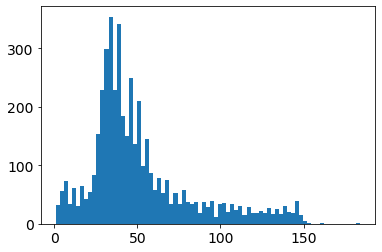

In [17]:
#identify maximum peaks for PPP/PIC
def call_peaks_max(signal_df, gtf_df, dataset, min_pos, max_pos, min_cov):
    signal=signal_df.loc[(signal_df['dataset']==dataset)&(signal_df['pos'].isin(np.arange(min_pos, max_pos)))]

    peak_dic={}
    for gene in gtf_df.loc[gtf_df['biotype']=='protein_coding']['gid']:
        peak = np.argmax(signal[gene].to_numpy())
        if np.amax(signal[gene].to_numpy()) > min_cov:
            peak_dic[gene]=peak+min_pos
    return peak_dic

pro_peaks_max=call_peaks_max(signal_df, gtf_df, 'PRO_fwd', 0, 150, 10)
cage_peaks_max=call_peaks_max(signal_df, gtf_df, 'CAGE_fwd', -50,50, 10)

#distance between max peaks
max_dists={}
for g in pro_peaks_max:
    if g in cage_peaks_max:
        if pro_peaks_max[g]>cage_peaks_max[g]:
            max_dists[g]=pro_peaks_max[g]-cage_peaks_max[g]
        
gtf_df['PPP_PIC_dist']=gtf_df['gid'].map(max_dists)
plt.hist(gtf_df['PPP_PIC_dist'].dropna(), bins=75)
plt.show()

In [18]:
#count co-occupancy events
p_values=[]
yyt=[]
ynt=[]
nyt=[]
nnt=[]
dists=[]
gs=[]

l=0
k=0
for index, row in gtf_df.loc[~gtf_df['PPP_PIC_dist'].isna()].iterrows():
    g=row['gid']
    
    if g in pause_reads:
        if g in pic_reads:
            
            dist = row['PPP_PIC_dist']

            reads = np.array(ndr_reads[g])
            
            pause = np.array(pause_reads[g])
            
            pic=np.array(pic_reads[g])
              
            y1=pause
            y2=pic

            n1=np.setxor1d(reads, pause)
            n2=np.setxor1d(reads, pic)

            yy=np.intersect1d(y1, y2)
            yn=np.intersect1d(y1, n2)
            ny=np.intersect1d(n1, y2)
            nn=np.intersect1d(n1, n2)

            yyt.append(len(yy))
            nyt.append(len(ny))
            ynt.append(len(yn))
            nnt.append(len(nn))
            dists.append(dist)
            gs.append(g)

    l+=1
    if l%2000==0:
        print(l)

t=pd.DataFrame()
t['yy']=yyt
t['ny']=nyt
t['yn']=ynt
t['nn']=nnt
t['dists']=dists
t['g']=gs


2000
4000


[[3, 393], [330, 12946]]
0
SignificanceResult(statistic=0.2994679620633819, pvalue=0.02016918017039836)
[[13, 1306], [855, 33048]]
15
SignificanceResult(statistic=0.384750544047715, pvalue=0.00012579509931227924)
[[44, 4982], [3244, 102820]]
30
SignificanceResult(statistic=0.27992759136343365, pvalue=6.149042813231236e-25)
[[29, 2441], [1671, 58969]]
45
SignificanceResult(statistic=0.4192543058674239, pvalue=1.659823639776431e-07)
[[13, 679], [557, 21114]]
60
SignificanceResult(statistic=0.7257531008479573, pvalue=0.32521110991033353)
[[7, 292], [252, 10560]]
75
SignificanceResult(statistic=1.004566210045662, pvalue=1.0)


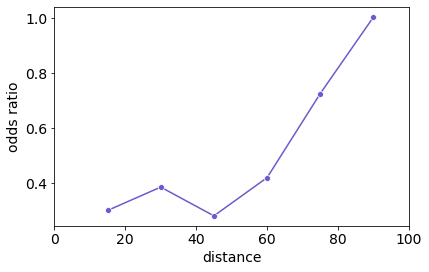

In [19]:
#plot co-occupancy event frequency w.r.t. distance 
d=[0,15,30,45,60,75,90]
t_d=pd.DataFrame()
pss=[]
statss=[]

for i in range(len(d)-1):

    tmp=t.loc[(t['dists']>=d[i])&(t['dists']<d[i+1])]
    tests=[]
    tmp['y1']=tmp['yn']+tmp['yy']
    tmp['y2']=tmp['ny']+tmp['yy']
    a=tmp.sum(axis=0)
    ps=[]
    for index, row in tmp.iterrows():
        table=[[row['yy'],row['yn']],[row['ny'],row['nn']]]
        ps.append(scipy.stats.fisher_exact(table)[1])

    tmp['p']=ps
    table=[[a['yy'],a['yn']],[a['ny'],a['nn']]]
    print(table)
    print(d[i])
    print(scipy.stats.fisher_exact(table))
    pss.append(np.log10(scipy.stats.fisher_exact(table)[1]))
    statss.append((scipy.stats.fisher_exact(table)[0]))
    
    
ts1=pd.DataFrame([np.array(d[1:]),statss,pss]).T
ts1.columns=['distance','odds ratio','p value']


plt.figure(figsize=(6,4))
sns.lineplot(data=ts1, x='distance',y='odds ratio', color='slateblue', marker='o')
plt.tight_layout()
plt.xlim(0,100)
#plt.savefig('Paper Figures Updated/Figure 3/coordination/PPP+PIC_single/fisher_odds.pdf')
#plt.savefig('Paper Figures Updated/Figure 3/coordination/PPP+PIC_single/fisher_odds.png')
plt.show()


# Transcribed enhancers

## Footprint size enrichment

In [52]:
#import enhancer data
s=-550
e=550
genes_df=pd.DataFrame()

for f in os.listdir('HMM_footprint_caller-v2/Pol-II_dm6/Processed/enhancers'):
    if 'untreated' in f and 'enhancers' in f:
        print(f)
        tmp=pd.read_csv('HMM_footprint_caller-v2/Pol-II_dm6/Processed/enhancers/'+f, sep='\t', usecols=np.append(['gid','rid','condition','dataset'],np.arange(s,e).astype(str)))#, nrows=3)
        genes_df=pd.concat([tmp, genes_df], axis=0)
genes_df.columns=genes_df.columns.astype(str)

enhancers_start_untreated_1.tsv
enhancers_start_untreated_2.tsv
enhancers_start_untreated_3.tsv
enhancers_start_untreated_4.tsv
enhancers_start_untreated_5.tsv
enhancers_start_untreated_6.tsv
enhancers_start_untreated_7.tsv


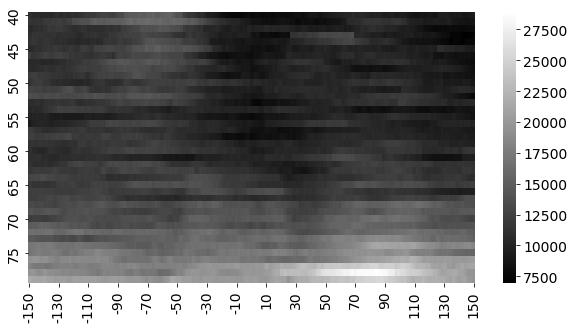

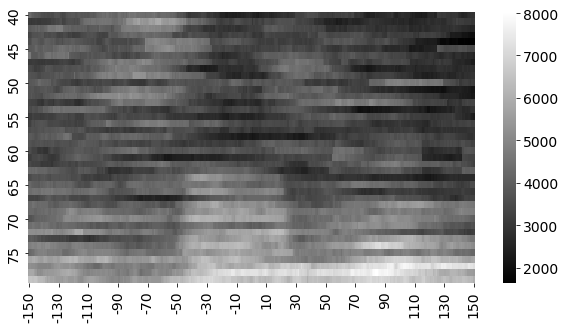

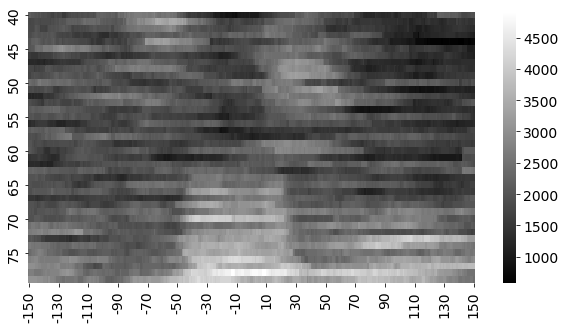

In [55]:
bin_size=1
min_size=40
max_size=80
start=-150
end=151
min_cts=[10,50,100]
for min_ct in min_cts:

    gs=gtf_df.loc[gtf_df['PRC_peak']>=min_ct]['gid']
    genes_tmp=genes_df.loc[genes_df['gid'].isin(gs)]

    meta=plot_meta_heatmap(genes_tmp, start, end, min_size, max_size, bin_size)

    fig, ax=plt.subplots(1,1,figsize=(10,5))
    sns.heatmap(data=meta, cbar=True, cmap='gray', ax=ax, xticklabels=20, yticklabels=5)#,vmax=30000)
    #plt.savefig('Paper Figures Updated/Figure 3/eRNAs_START/enhancer-heatmap_'+str(min_ct)+'.png')
    #plt.savefig('Paper Figures Updated/Figure 3/eRNAs_START/enhancer-heatmap_'+str(min_ct)+'.pdf')
    plt.show()

## Transcription footprint enrichment

4077


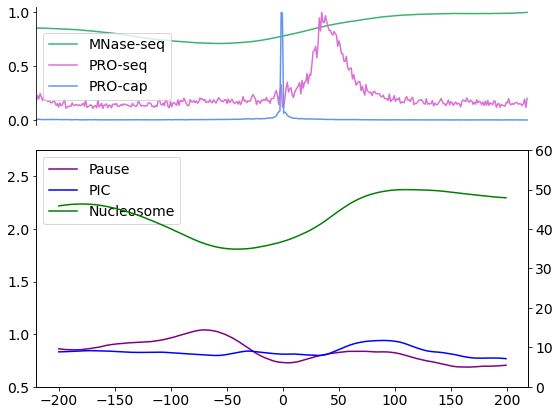

1138


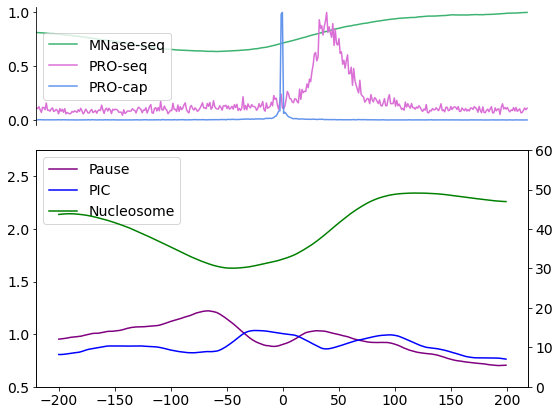

593


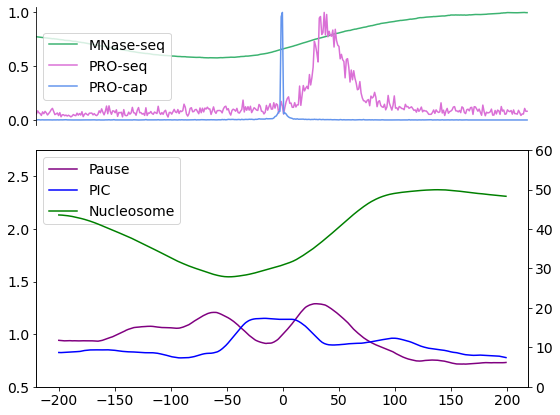

142


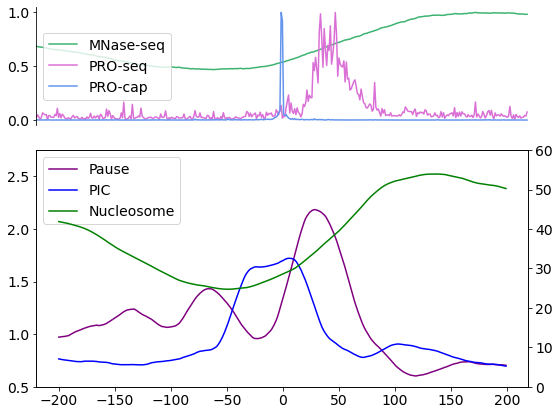

In [66]:
# a lot of variables are "PRC (pro-cap)" but actually refer to START-seq data, because I switched after writing all these scripts

s=-200
e=200
smooth=25
min_ct=5

#START-seq cutoffs
min_cts=[10,50,100,500]
for min_ct in min_cts:
    gs=gtf_df.loc[gtf_df['PRC_peak']>=min_ct]['gid']
    print(len(gs))
    genes_tmp=genes_df.loc[genes_df['gid'].isin(gs)]

    genes=genes_tmp['gid'].unique()

    mnase_fwd = signal_df.loc[signal_df['dataset']=='mnase_15']
    mnase_fwd=mnase_fwd.loc[mnase_fwd['pos'].isin(np.arange(s,e))]
    mnase_fwd=mnase_fwd[[col for col in genes if col in mnase_fwd.columns]]
    tmp_sum = mnase_fwd.sum(axis=0)
    mnase_fwd = mnase_fwd/tmp_sum
    mnase_fwd = mnase_fwd.sum(axis=1)
    mnase_fwd = mnase_fwd/max(mnase_fwd)

    PRO_fwd = signal_df.loc[signal_df['dataset']=='PRO_fwd']
    PRO_fwd=PRO_fwd.loc[PRO_fwd['pos'].isin(np.arange(s,e))]
    PRO_fwd=PRO_fwd[[col for col in genes if col in PRO_fwd.columns]]
    tmp_sum = PRO_fwd.sum(axis=0)
    PRO_fwd = PRO_fwd/tmp_sum
    PRO_fwd = PRO_fwd.sum(axis=1)

    PRC_fwd = signal_df.loc[signal_df['dataset']=='START_fwd']
    PRC_fwd=PRC_fwd.loc[PRC_fwd['pos'].isin(np.arange(s,e))]
    PRC_fwd=PRC_fwd[[col for col in genes if col in PRC_fwd.columns]]
    tmp_sum = PRC_fwd.sum(axis=0)
    PRC_fwd = PRC_fwd/tmp_sum
    PRC_fwd = PRC_fwd.sum(axis=1)

    PRO_fwd = PRO_fwd/max(PRO_fwd)
    PRC_fwd = PRC_fwd/max(PRC_fwd)


    #plot other datasets
    fig, ax= plt.subplots(2,1,figsize=(8,6),gridspec_kw={'height_ratios': [2,4]})
    ax[0].plot(np.arange(s,e),mnase_fwd, color='mediumseagreen', label='MNase-seq')
    ax[0].plot(np.arange(s,e),PRO_fwd, color='orchid', label='PRO-seq')
    ax[0].plot(np.arange(s,e),PRC_fwd, color='cornflowerblue', label='PRO-cap')
    ax[0].set_xlim(s,e)
    ax[0].legend(loc='center left')
    ax[0].set_xticks([])
    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    ax[0].spines['bottom'].set_visible(False)

    #generate Fiber-seq enrichment
    b=meta_line_plot(genes_tmp, s-smooth, e+smooth, 40, 60, False)
    c=meta_line_plot(genes_tmp, s-smooth, e+smooth, 60, 80, False)
    d=meta_line_plot(genes_tmp, s-smooth, e+smooth, 90, 300, False)

    #smoothing
    box = np.ones(smooth)/smooth
    b = np.convolve(b, box, mode='same')
    b=b[smooth:len(b)-smooth]
    c = np.convolve(c, box, mode='same')
    c=c[smooth:len(c)-smooth]        
    d = np.convolve(d, box, mode='same')
    d=d[smooth:len(d)-smooth]

    #plot Fiber-seq enrichment
    l1 = ax[1].plot(np.arange(s,e),b*100, color='purple',label='Pause')
    l2 = ax[1].plot(np.arange(s,e),c*100, color='blue',label='PIC')
    ax3 = ax[1].twinx() 
    l3 = ax3.plot(np.arange(s,e),d*100, color='green',label='Nucleosome')
    ls = l1+l2+l3
    labs = [l.get_label() for l in ls]
    ax[1].legend(ls, labs, loc='upper left')
    #if min_ct <=100:
    ax3.set_ylim(0,60)
    ax[1].set_ylim(0.5,2.75)

    #save plot
    plt.tight_layout()
    plt.savefig('Paper Figures Updated/Figure 3/eRNAs_START/enhancer-enrichment_'+str(min_ct)+'_orth.png')
    plt.savefig('Paper Figures Updated/Figure 3/eRNAs_START/enhancer-enrichment_'+str(min_ct)+'_orth.pdf')
    plt.show()


## Transcription footprint quantification

In [57]:
#import both enhancers and coding genes
s=-200
e=200
genes_df=pd.DataFrame()

for f in os.listdir('HMM_footprint_caller-v2/Pol-II_dm6/Processed/enhancers'):
    if 'untreated' in f and 'enhancers' in f:
        print(f)
        tmp=pd.read_csv('HMM_footprint_caller-v2/Pol-II_dm6/Processed/enhancers/'+f, sep='\t', usecols=np.append(['gid','rid','condition','dataset'],np.arange(s,e).astype(str)))#, nrows=3)
        genes_df=pd.concat([tmp, genes_df], axis=0)
        
for f in os.listdir('HMM_footprint_caller-v2/Pol-II_dm6/Processed'):
    if 'untreated' in f and '_coding' in f:
        print(f)
        tmp=pd.read_csv('HMM_footprint_caller-v2/Pol-II_dm6/Processed/'+f, sep='\t', usecols=np.append(['gid','rid','condition','dataset'],np.arange(s,e).astype(str)))#, nrows=3)
        genes_df=pd.concat([tmp, genes_df], axis=0)
        
genes_df.columns=genes_df.columns.astype(str)

enhancers_start_untreated_1.tsv
enhancers_start_untreated_2.tsv
enhancers_start_untreated_3.tsv
enhancers_start_untreated_4.tsv
enhancers_start_untreated_5.tsv
enhancers_start_untreated_6.tsv
enhancers_start_untreated_7.tsv
2000-2000_coding_untreated_1.tsv
2000-2000_coding_untreated_2.tsv
2000-2000_coding_untreated_3.tsv
2000-2000_coding_untreated_4.tsv
2000-2000_coding_untreated_5.tsv
2000-2000_coding_untreated_6.tsv
2000-2000_coding_untreated_7.tsv


In [58]:
s=-200
e=200

start=-20
end=20
min_size=90
max_size=10000

print('ndr reads')
ndr_reads=genes_df.loc[(genes_df['condition']=='untreated')&(~genes_df.loc[:,np.arange(start,end).astype(str)].isin(np.arange(min_size,max_size)).any(axis=1))]
print(ndr_reads.shape)

ndr_reads=ndr_reads.drop(['dataset'], axis=1).fillna(0)
print('peaks')
pro_peaks=call_peaks(signal_df, gtf_df, 'PRO_fwd', 0, 100, 20, 10, 5, 0)
cage_peaks=call_peaks(signal_df, gtf_df, 'START_fwd', -50, 50, 20, 10, 5, 0)
ndr_reads['rid,gid']=ndr_reads['rid']+','+ndr_reads['gid']


print('hits pause')
hits_pause, nohits_pause=call_hits(ndr_reads, 40, 60, 1/.01, pro_peaks, s)
print(len(hits_pause), len(nohits_pause))
pause_reads=ndr_reads.loc[ndr_reads['rid,gid'].isin(hits_pause)]

print('hits pic')
hits_pic, nohits_pic=call_hits(ndr_reads, 61, 80, 1/.01, cage_peaks, s)
print(len(hits_pic), len(nohits_pic))
pic_reads=ndr_reads.loc[ndr_reads['rid,gid'].isin(hits_pic)]

print('nopic')
no_pic_pause=np.intersect1d(np.array(nohits_pause), np.array(nohits_pic))
no_pic_pause=ndr_reads.loc[ndr_reads['rid,gid'].isin(no_pic_pause)]

no_pic_pause=no_pic_pause[['rid','gid', 'rid,gid']]
pic_reads=pic_reads[['rid','gid', 'rid,gid']]
pause_reads=pause_reads[['rid','gid', 'rid,gid']]
ndr_reads=ndr_reads[['rid','gid', 'rid,gid']]
pp_reads=ndr_reads.loc[(ndr_reads['rid,gid'].isin(pause_reads['rid,gid']))|(ndr_reads['rid,gid'].isin(pic_reads['rid,gid']))]



ndr reads
(1631320, 404)
peaks
hits pause
1000000
19561 1611759
hits pic
1000000
19409 1611911
nopic


In [59]:
#this is a really inefficient way to do this
pic_g={}
ppp_g={}
ndr_g={}
all_g={}
i=0
for gid in genes_df['gid'].unique():
    pic_g[gid]=pic_reads.loc[pic_reads['gid']==gid].shape[0]
    ppp_g[gid]=pause_reads.loc[pause_reads['gid']==gid].shape[0]
    ndr_g[gid]=ndr_reads.loc[ndr_reads['gid']==gid].shape[0]
    all_g[gid]=genes_df.loc[genes_df['gid']==gid].shape[0]
    i+=1
    if i%1000==0:
        print(i)

gtf_df['pic_ct']=gtf_df['gid'].map(pic_g)
gtf_df['ppp_ct']=gtf_df['gid'].map(ppp_g)
gtf_df['ndr_ct']=gtf_df['gid'].map(ndr_g)
gtf_df['all_ct']=gtf_df['gid'].map(all_g)
print(gtf_df)

1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
       Unnamed: 0  chrom        type     start       end strand  \
0               0  chr2L  transcript      7529      9484      +   
1               1  chr2L  transcript      9839     21376      -   
2               2  chr2L  transcript     21823     25155      -   
3               3  chr2L  transcript     21952     24237      +   
4               4  chr2L  transcript     25402     59268      -   
...           ...    ...         ...       ...       ...    ...   
21840       21840   chrX         NaN  23007289  23007290      +   
21841       21841   chrX         NaN  23006953  23006954      -   
21842       21842   chrX         NaN  23216163  23216164      +   
21843       21843   chrY         NaN   1870530   1870531      +   
21844       21844   chrY         NaN   3013054   3013055      +   

                                                    meta   length  \
0      gene_id "FBgn0031208"; tra

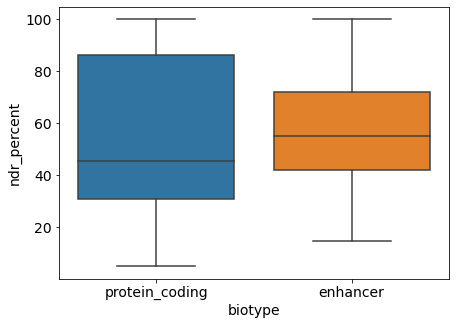

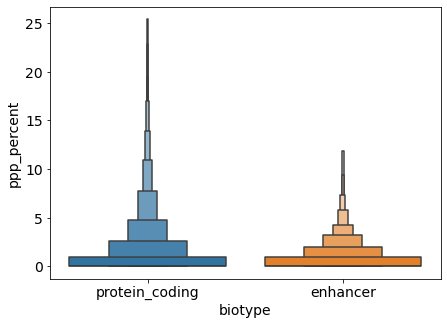

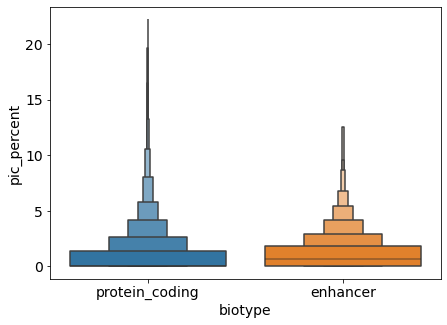

ndr mean
55.966077426283306
57.63718576292004
ppp mean
1.040762858826016
0.7006079841707004
pic mean
0.9922234622241688
1.2404175593783462
ranksums
RanksumsResult(statistic=-9.382906272582826, pvalue=6.417882146006502e-21)
RanksumsResult(statistic=1.5136185357844998, pvalue=0.13012261717636192)
RanksumsResult(statistic=-15.390961382308124, pvalue=1.8821489109465524e-53)


In [60]:
gt=gtf_df.loc[gtf_df['biotype'].isin(['protein_coding','enhancer'])]
gt['ppp_percent']=(gt['ppp_ct']/gt['ndr_ct'])*100
gt['pic_percent']=(gt['pic_ct']/gt['ndr_ct'])*100

gt=gtf_df.loc[gtf_df['biotype'].isin(['protein_coding','enhancer'])]
gt['ndr_percent']=(gt['ndr_ct']/gt['all_ct'])*100
plt.figure(figsize=(7,5))
sns.boxplot(data=gt.loc[(gt['ndr_percent']>=0)],y='ndr_percent', x='biotype', showfliers = False)#, log_scale=True)#,multiple="dodge")
#plt.savefig('Paper Figures Updated/Figure 3/eRNAs_START/quantification/NDR.png')
#plt.savefig('Paper Figures Updated/Figure 3/eRNAs_START/quantification/NDR.pdf')
plt.show()

gt['ppp_percent']=(gt['ppp_ct']/gt['ndr_ct'])*100
plt.figure(figsize=(7,5))
sns.boxenplot(data=gt.loc[(gt['ppp_percent']>=0)],y='ppp_percent', x='biotype', scale='exponential', showfliers = False)#, log_scale=True)#,multiple="dodge")
#plt.savefig('Paper Figures Updated/Figure 3/eRNAs_START/quantification/0_PPP.png')
#plt.savefig('Paper Figures Updated/Figure 3/eRNAs_START/quantification/0_PPP.pdf')
plt.show()

plt.figure(figsize=(7,5))
gt['pic_percent']=(gt['pic_ct']/gt['ndr_ct'])*100
sns.boxenplot(data=gt.loc[(gt['pic_percent']>=0)],y='pic_percent', x='biotype', scale='exponential', showfliers = False)#, log_scale=True)#,multiple="dodge")
#plt.savefig('Paper Figures Updated/Figure 3/eRNAs_START/quantification/0_PIC.png')
#plt.savefig('Paper Figures Updated/Figure 3/eRNAs_START/quantification/0_PIC.pdf')
plt.show()

print('ndr mean')
print(np.mean(gt.loc[gt['biotype']=='protein_coding']['ndr_percent']))
print(np.mean(gt.loc[gt['biotype']=='enhancer']['ndr_percent']))

print('ppp mean')
print(np.mean(gt.loc[gt['biotype']=='protein_coding']['ppp_percent']))
print(np.mean(gt.loc[gt['biotype']=='enhancer']['ppp_percent']))

print('pic mean')
print(np.mean(gt.loc[gt['biotype']=='protein_coding']['pic_percent']))
print(np.mean(gt.loc[gt['biotype']=='enhancer']['pic_percent']))


print('ranksums')
print(scipy.stats.ranksums(gt.loc[gt['biotype']=='protein_coding']['ndr_percent'].dropna(),gt.loc[gt['biotype']=='enhancer']['ndr_percent'].dropna()))
print(scipy.stats.ranksums(gt.loc[gt['biotype']=='protein_coding']['ppp_percent'].dropna(),gt.loc[gt['biotype']=='enhancer']['ppp_percent'].dropna()))
print(scipy.stats.ranksums(gt.loc[gt['biotype']=='protein_coding']['pic_percent'].dropna(),gt.loc[gt['biotype']=='enhancer']['pic_percent'].dropna()))


## Example transcribed enhancers

In [61]:
#import enhancer data
s=-550
e=550
genes_df=pd.DataFrame()

for f in os.listdir('HMM_footprint_caller-v2/Pol-II_dm6/Processed/enhancers'):
    if 'untreated' in f and 'enhancers' in f:
        print(f)
        tmp=pd.read_csv('HMM_footprint_caller-v2/Pol-II_dm6/Processed/enhancers/'+f, sep='\t', usecols=np.append(['gid','rid','condition','dataset'],np.arange(s,e).astype(str)))#, nrows=3)
        genes_df=pd.concat([tmp, genes_df], axis=0)
genes_df.columns=genes_df.columns.astype(str)

enhancers_start_untreated_1.tsv
enhancers_start_untreated_2.tsv
enhancers_start_untreated_3.tsv
enhancers_start_untreated_4.tsv
enhancers_start_untreated_5.tsv
enhancers_start_untreated_6.tsv
enhancers_start_untreated_7.tsv


In [62]:
#generate dictionary for each gene with list of peaks
def call_peaks(signal_df, gtf_df, dataset, min_pos, max_pos, window_size, min_threshold,min_cov,plot):
    
    #grab signal from dataframe
    signal=signal_df.loc[(signal_df['dataset']==dataset)]
    signal=signal.loc[signal['pos'].isin(np.arange(min_pos, max_pos))]
    
    peak_dic={}
    for gene in gtf_df['gid']:
        maxes=[]
        #identify minimum peak height given maximum peak and threshold
        #(min threshold is the minimum ratio of peak to the max peak at a gene)
        min_peak = np.amax(signal[gene].to_numpy())/min_threshold
        #iterate through windows
        for i in range(max_pos-min_pos):
            window=signal[gene].to_numpy()[i:i+window_size]
            #identify max in window and if it's above threshold (both in terms of ratio to maximum peak and also overall minimum peak height)
            if np.amax(window)>min_cov and np.amax(window)>min_peak:
                maxes.append(np.argmax(window)+i+min_pos)
        
        #return all unique peaks
        maxes=np.unique(np.array(maxes))
        if len(maxes)>0:
            peak_dic[gene]=maxes

    return peak_dic

#distance to start of footprint
def dist_to_fp(genes,gtf_df, s, e, min_size, max_size):
    a=genes.loc[:,np.arange(s,e).astype(str)]
    a=a.mask(a<min_size,0)
    a=a.mask(a>max_size,0)
    a=a.mask(a>=min_size,1)
    a=a.loc[a.sum(axis=1) > 1]
    a=a.idxmax(axis="columns")
    a=pd.DataFrame(a)
    a['gid']=a.index.map(dict(zip(genes.index,genes['gid'])))
    a['PI']=1
    a['PI']=np.log(a['PI'])
    a.columns=['d','gid','tr']
    a['d']=a['d'].astype(int)
    a=a.loc[a['d']>=s]
    return a

#size of footprint
def sizes_fp(genes,gtf_df,s, e, min_size, max_size):
    a=genes.loc[:,np.arange(s,e).astype(str)]
    a=a.mask(a<min_size,0)
    a=a.mask(a>max_size,0)
    a=a.replace(0, np.nan).bfill(1).iloc[:, 0].dropna()
    a=pd.DataFrame(a)
    a['gid']=a.index.map(dict(zip(genes.index,genes['gid'])))
    a['PI']=1
    a['PI']=np.log(a['PI'])
    a.columns=['d','gid','tr']
    a['d']=a['d'].astype(int)
    a=a.loc[a['d']!=s]
    return a

In [63]:
def make_cp(colors, sizes):
    
    #start at empty RGBA
    cp =[tuple([0,0,0,0])]*sizes[0]
    
    #iterate through size range checkpoints
    for i in range(len(colors)-1):
        #grab colors provided
        cs=Color(colors[i])
        ce=Color(colors[i+1])
        #interpolate RGBA values from one color to next for each size between size range provided
        for j in list(cs.range_to(ce, sizes[i+1]-sizes[i])):
            j=list(j.rgb)
            j.append(1)
            j=tuple(j)
            cp.append(j)

    return matplotlib.colors.ListedColormap(cp)

#basic colorprofile for small footprints
colors=['#ed306f','#e42cf6','#f3aafa','#265de6','#33a040'] 
sizes=[20,            45,        55,   70,         100]
pol_cp=make_cp(colors, sizes)

#grey colorprofile for blocking unknown footprints
colors=['#949494','#949494'] 
sizes=[1,  1000]
mask_cp=make_cp(colors, sizes)

#green colorprofile for nucleosomes
colors==['#33a040','#33a040']
sizes=[20,  1000]
nuc_cp=make_cp(colors, sizes)

In [64]:
start=-20
end=20
min_size=80
max_size=10000
condition='untreated'

pro_peaks=call_peaks(signal_df, gtf_df.loc[gtf_df['biotype']=='enhancer'], 'PRO_fwd', -0, 350, 20, 20, 5, 0)
start_peaks=call_peaks(signal_df, gtf_df.loc[gtf_df['biotype']=='enhancer'], 'START_fwd', -50,50, 20, 20, 5, 0)

593
e_17_0 17775    chr2L:128639
Name: chrom, dtype: object 17775    -
Name: strand, dtype: object


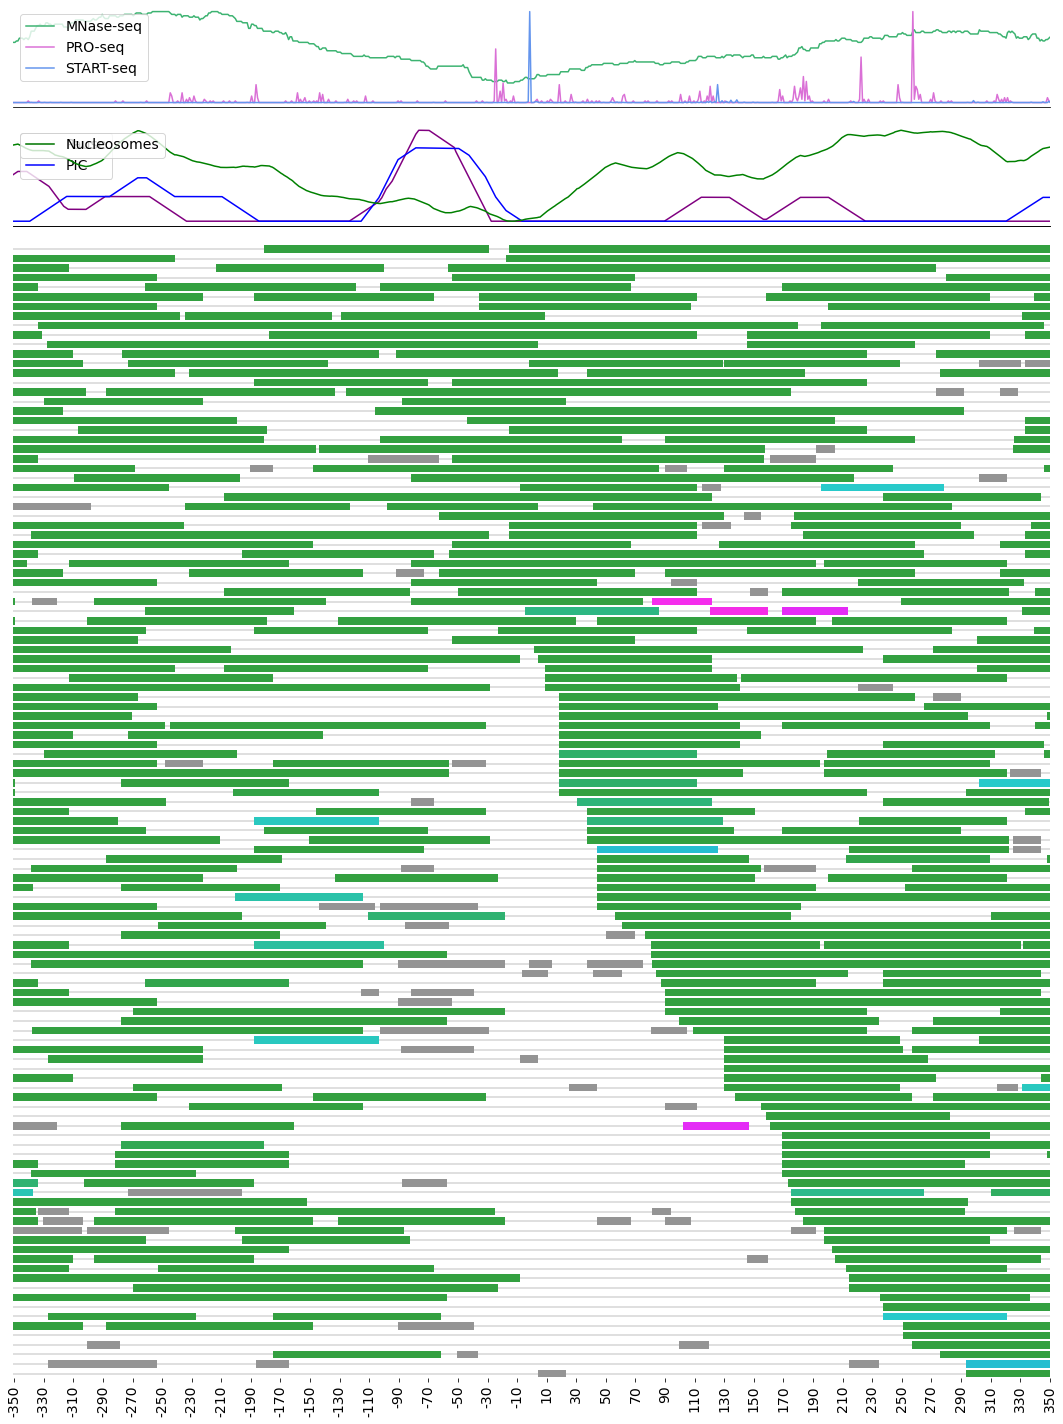

e_25_0 17780    chr2L:161449
Name: chrom, dtype: object 17780    -
Name: strand, dtype: object


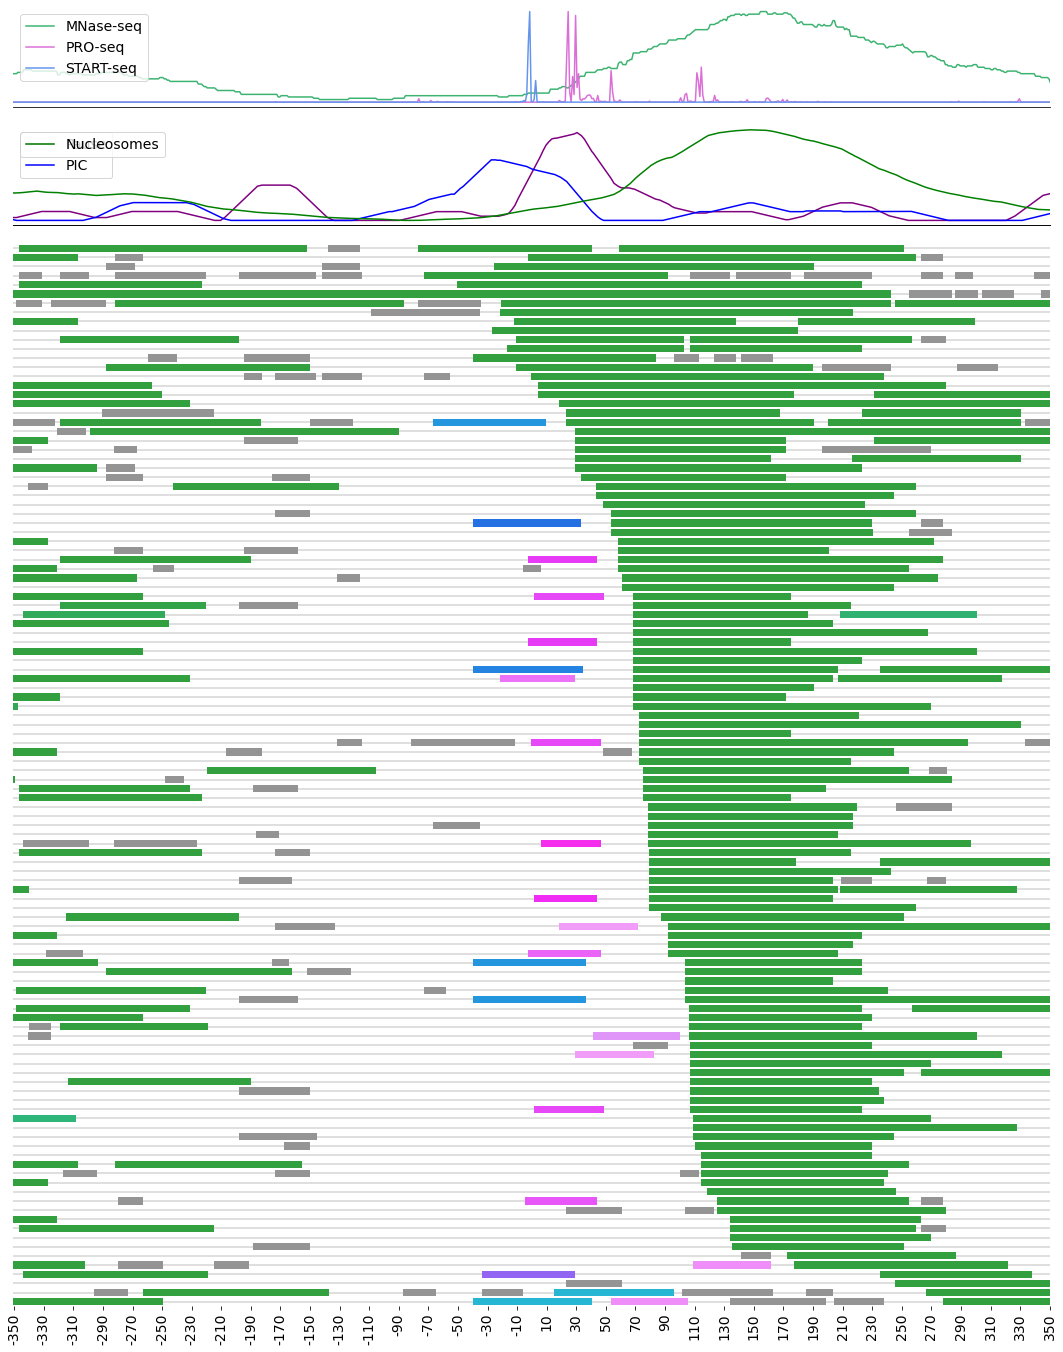

e_71_0 17805    chr2L:469476
Name: chrom, dtype: object 17805    +
Name: strand, dtype: object


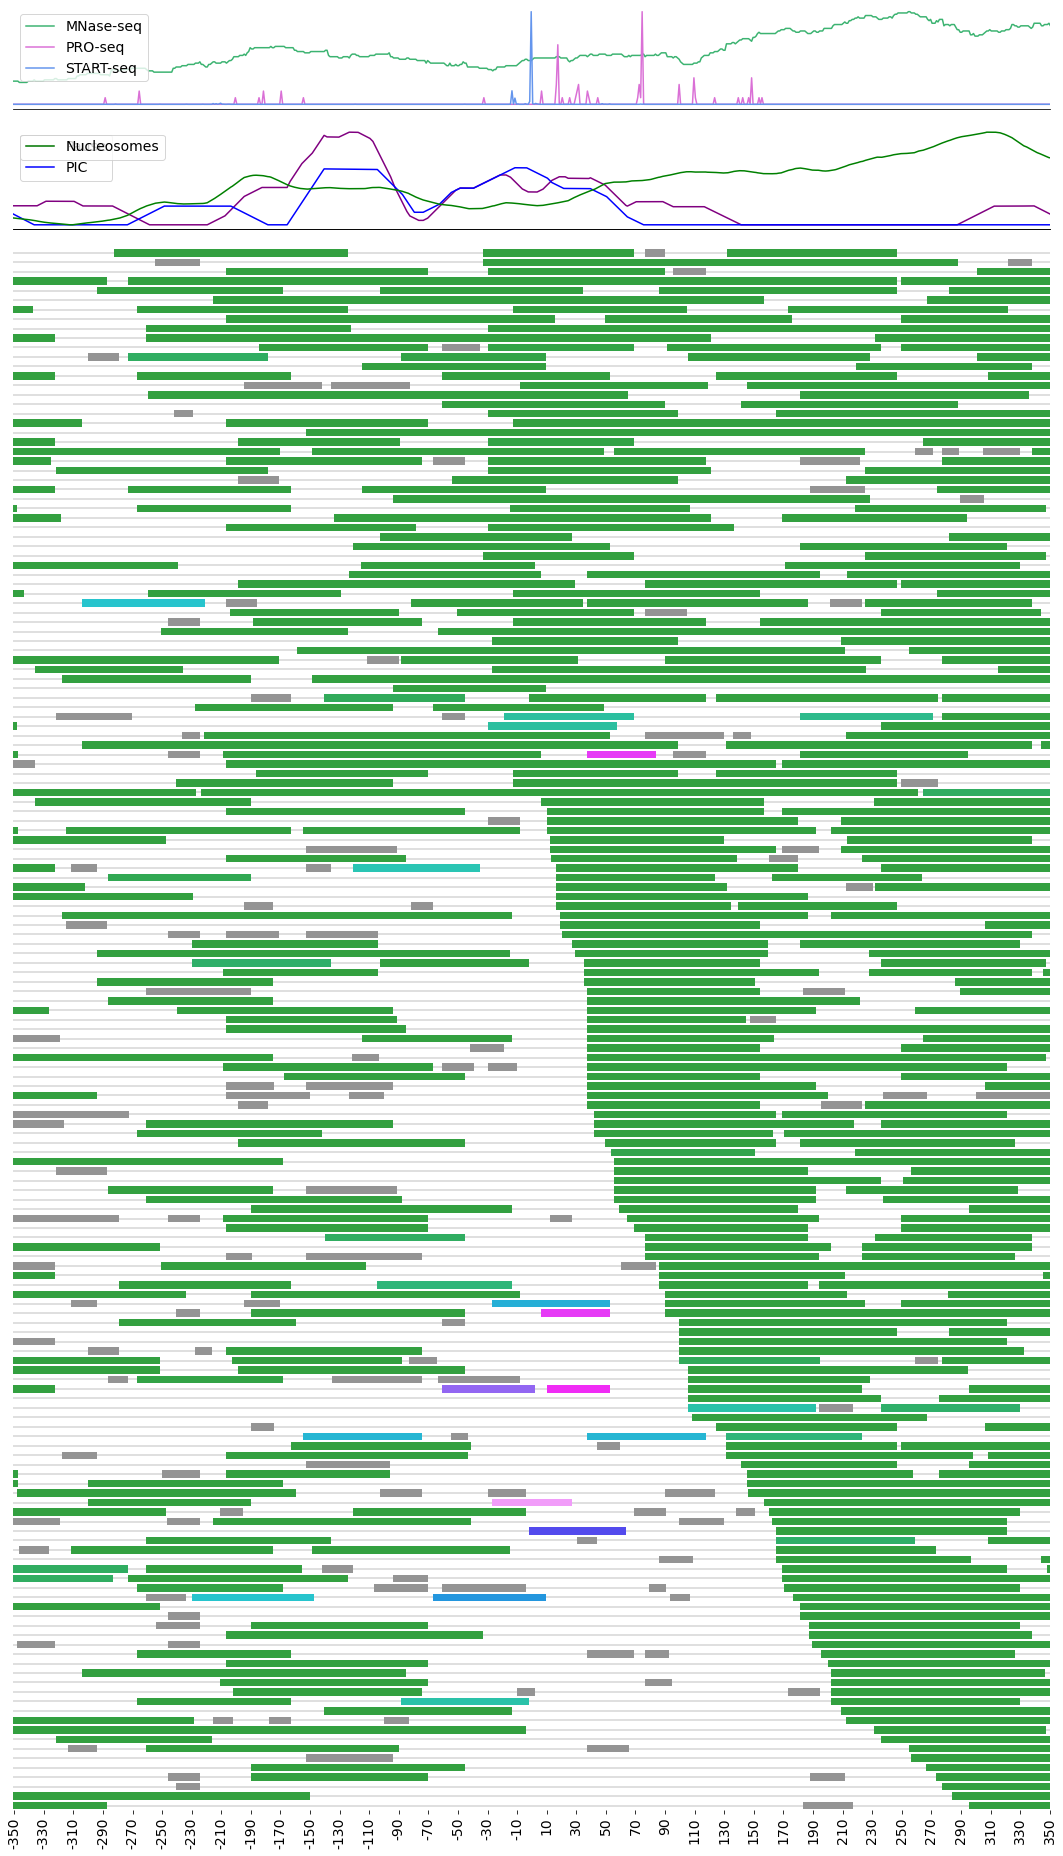

e_136_0 17836    chr2L:866476
Name: chrom, dtype: object 17836    -
Name: strand, dtype: object


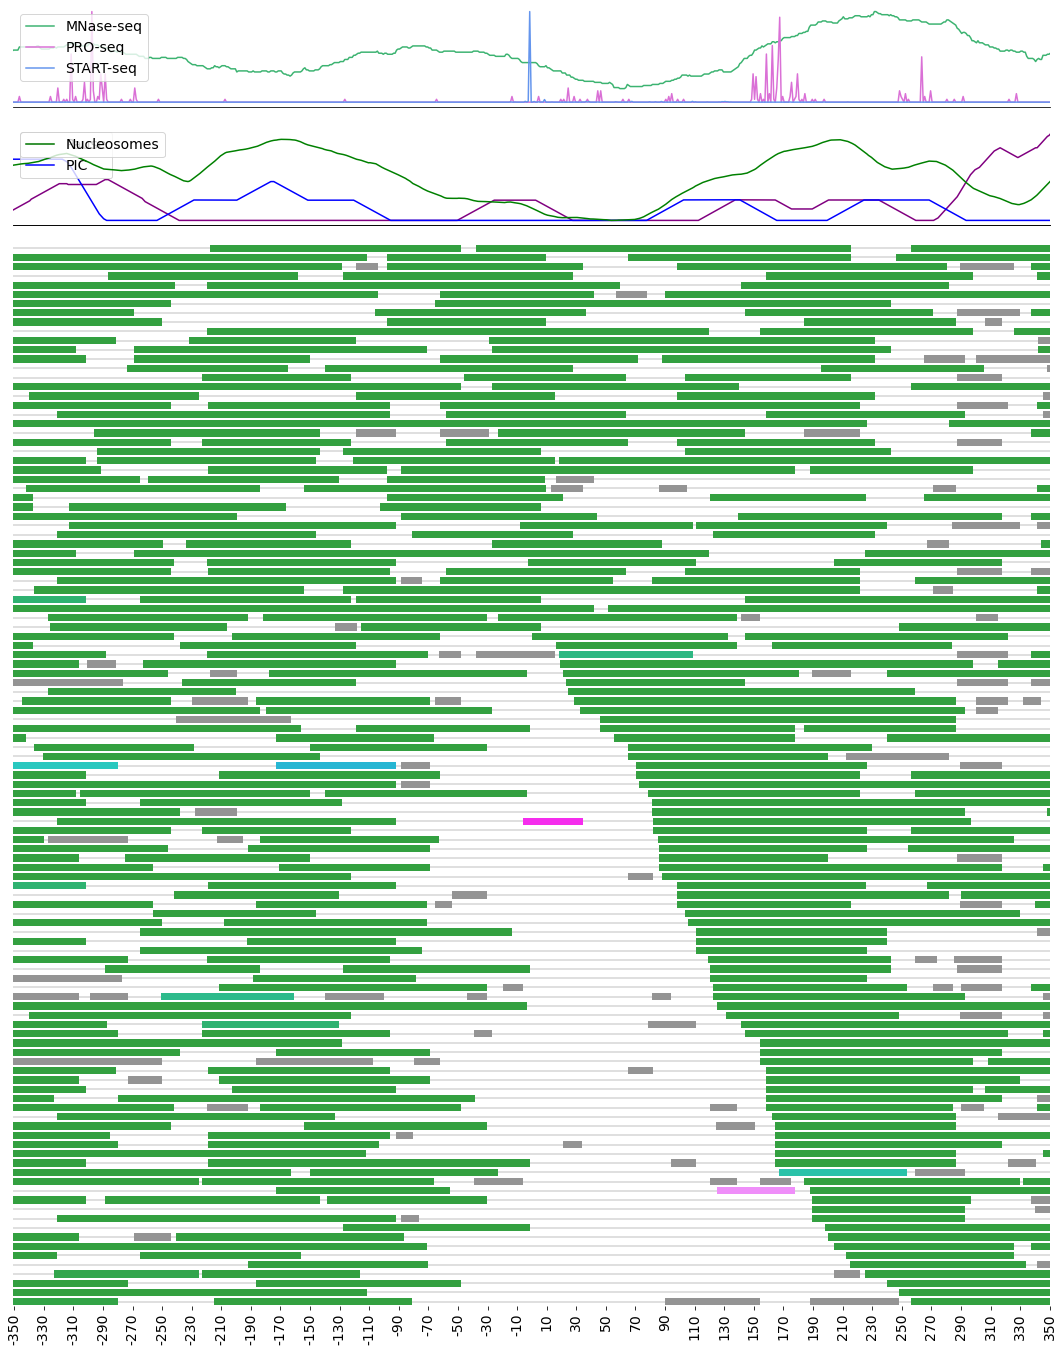

e_182_0 17850    chr2L:1424902
Name: chrom, dtype: object 17850    +
Name: strand, dtype: object


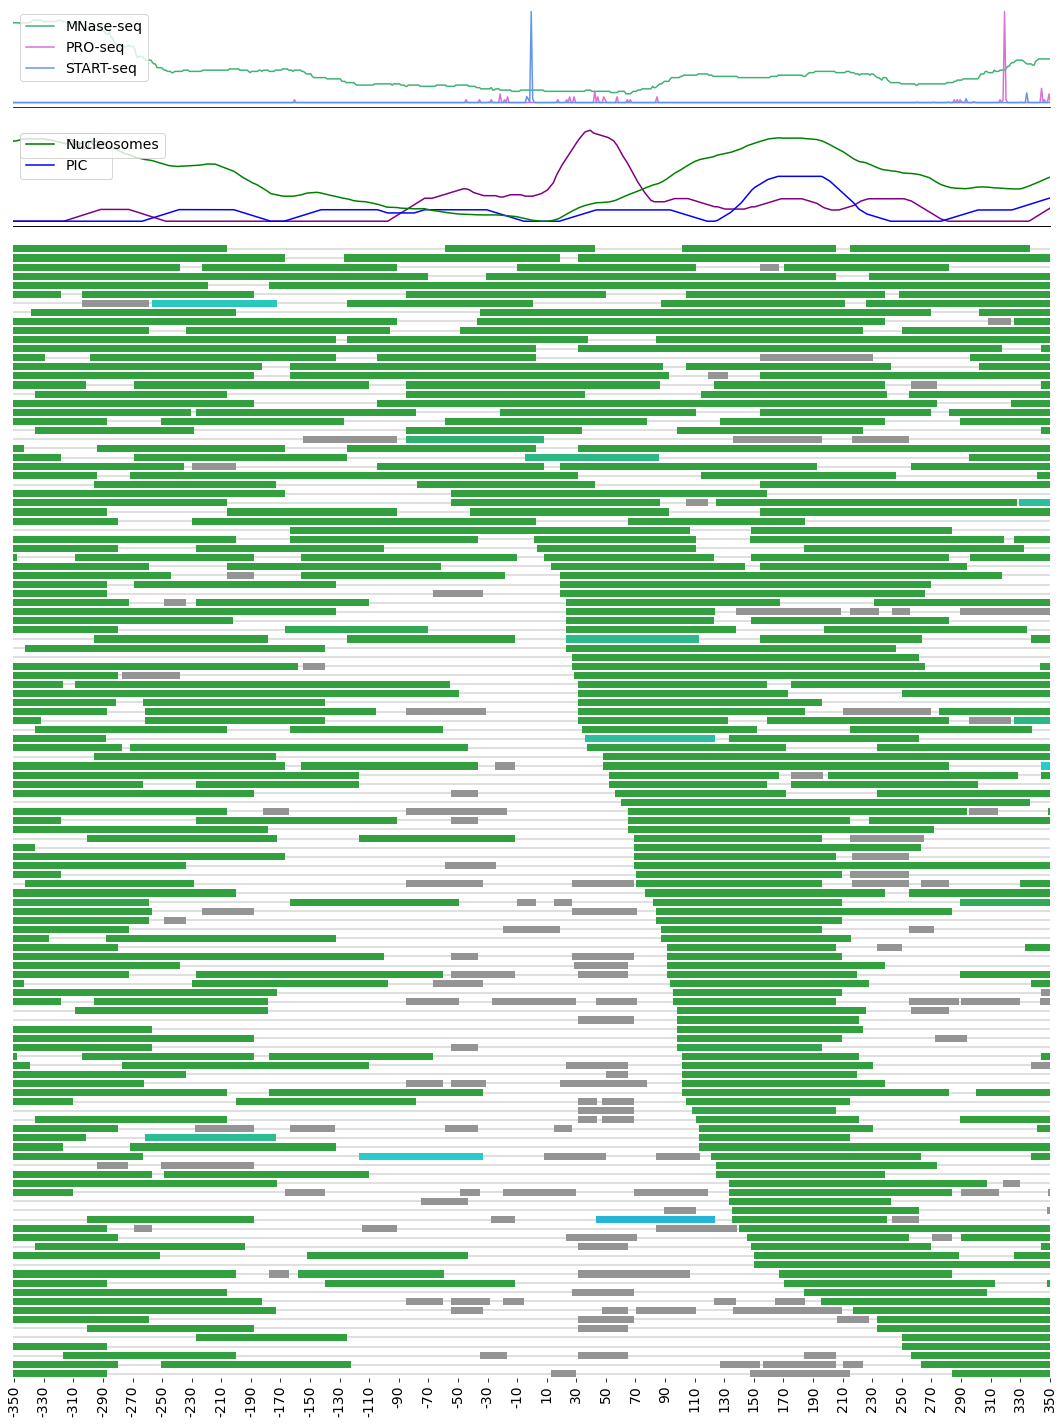

e_248_0 17864    chr2L:2161065
Name: chrom, dtype: object 17864    -
Name: strand, dtype: object


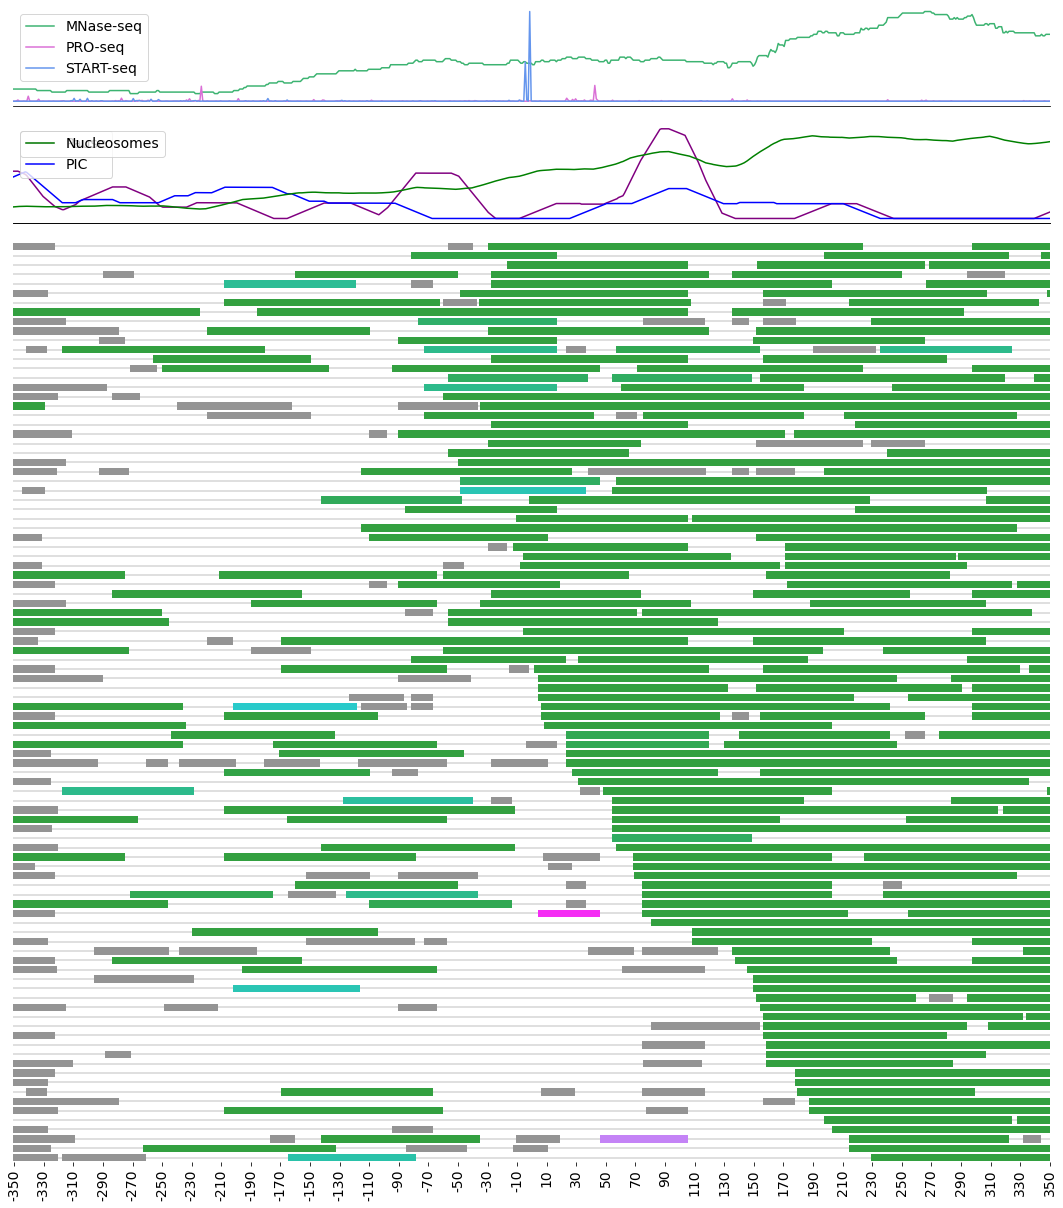

e_253_0 17869    chr2L:2167421
Name: chrom, dtype: object 17869    -
Name: strand, dtype: object


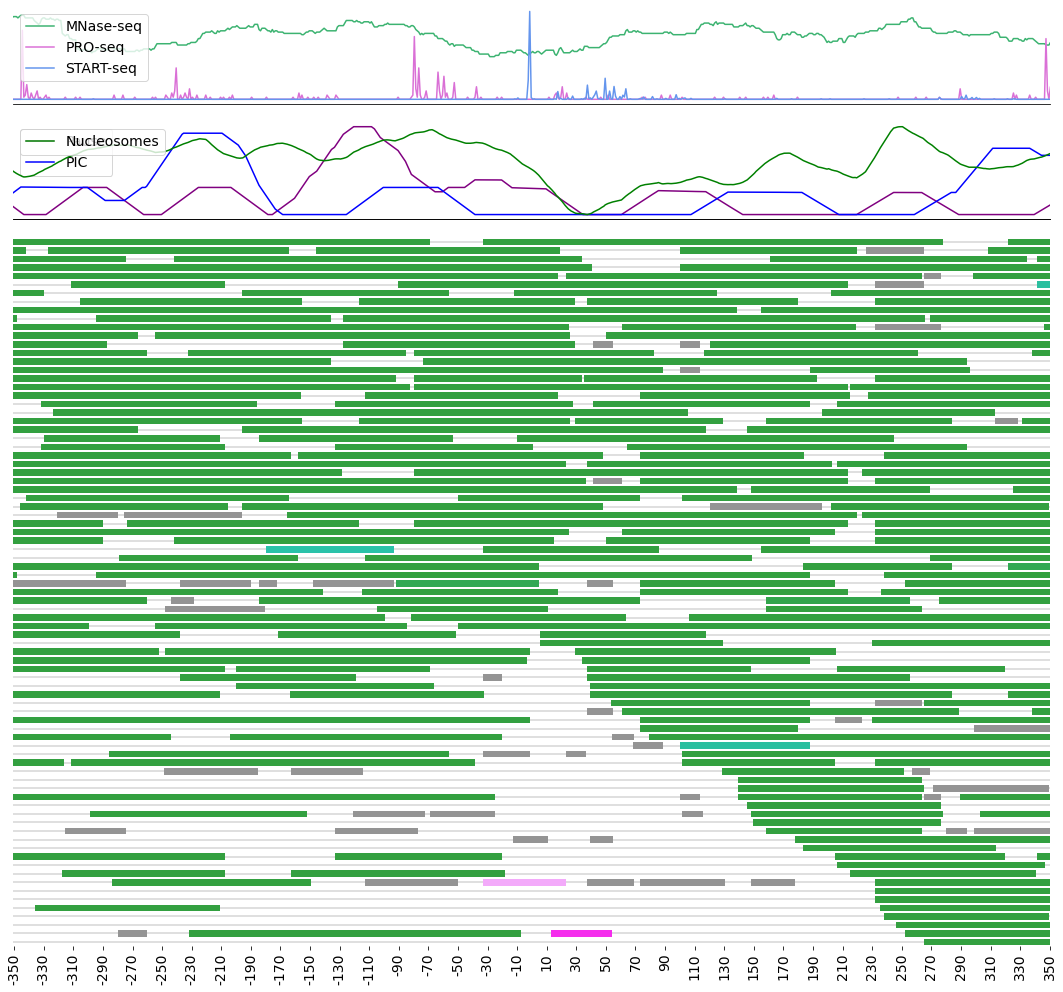

e_268_0 17879    chr2L:2229323
Name: chrom, dtype: object 17879    -
Name: strand, dtype: object


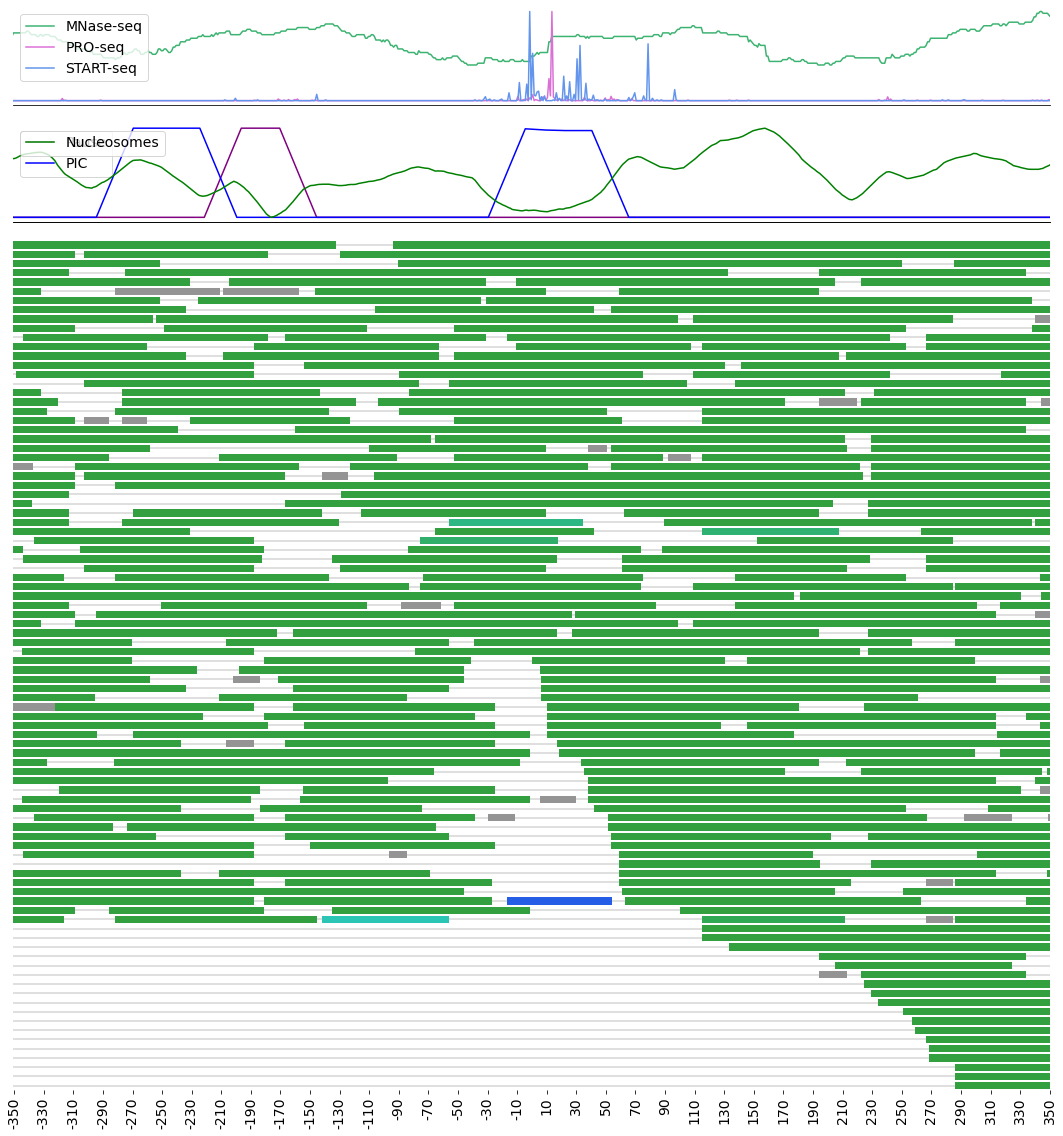

e_304_0 17886    chr2L:2751854
Name: chrom, dtype: object 17886    -
Name: strand, dtype: object


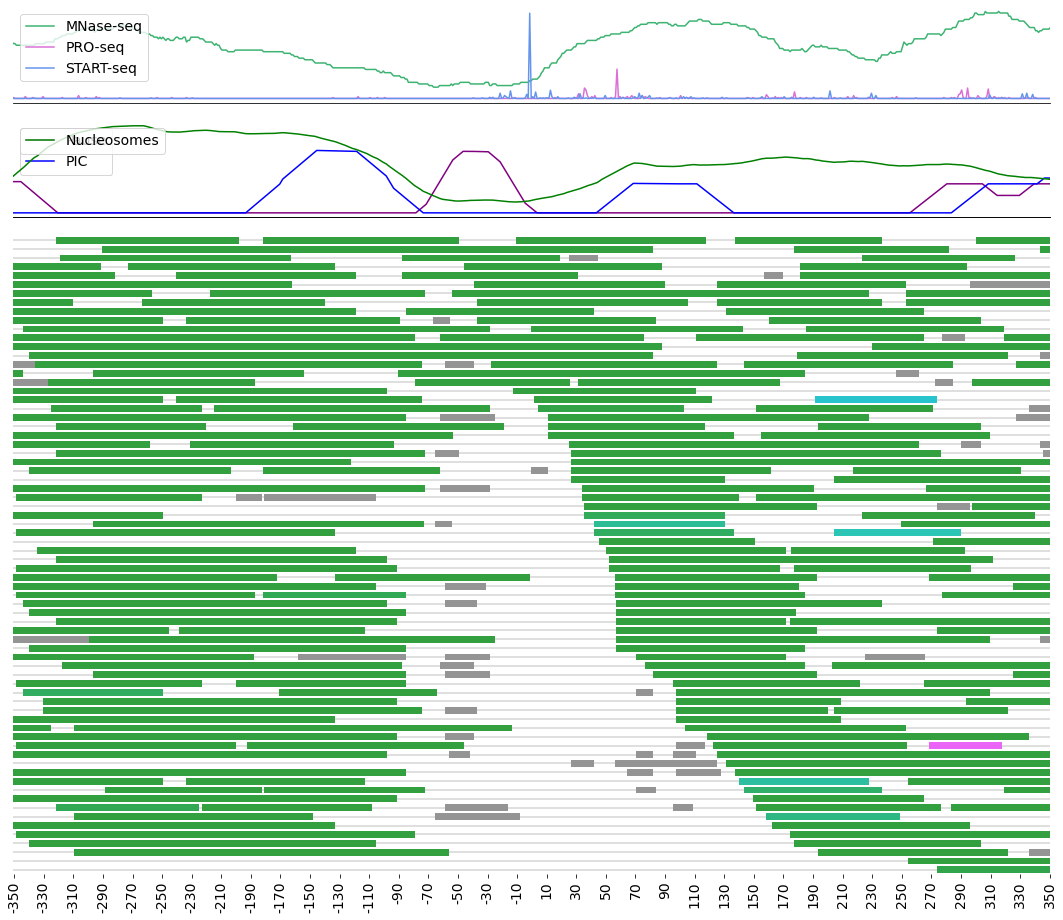

e_344_0 17899    chr2L:2993672
Name: chrom, dtype: object 17899    +
Name: strand, dtype: object


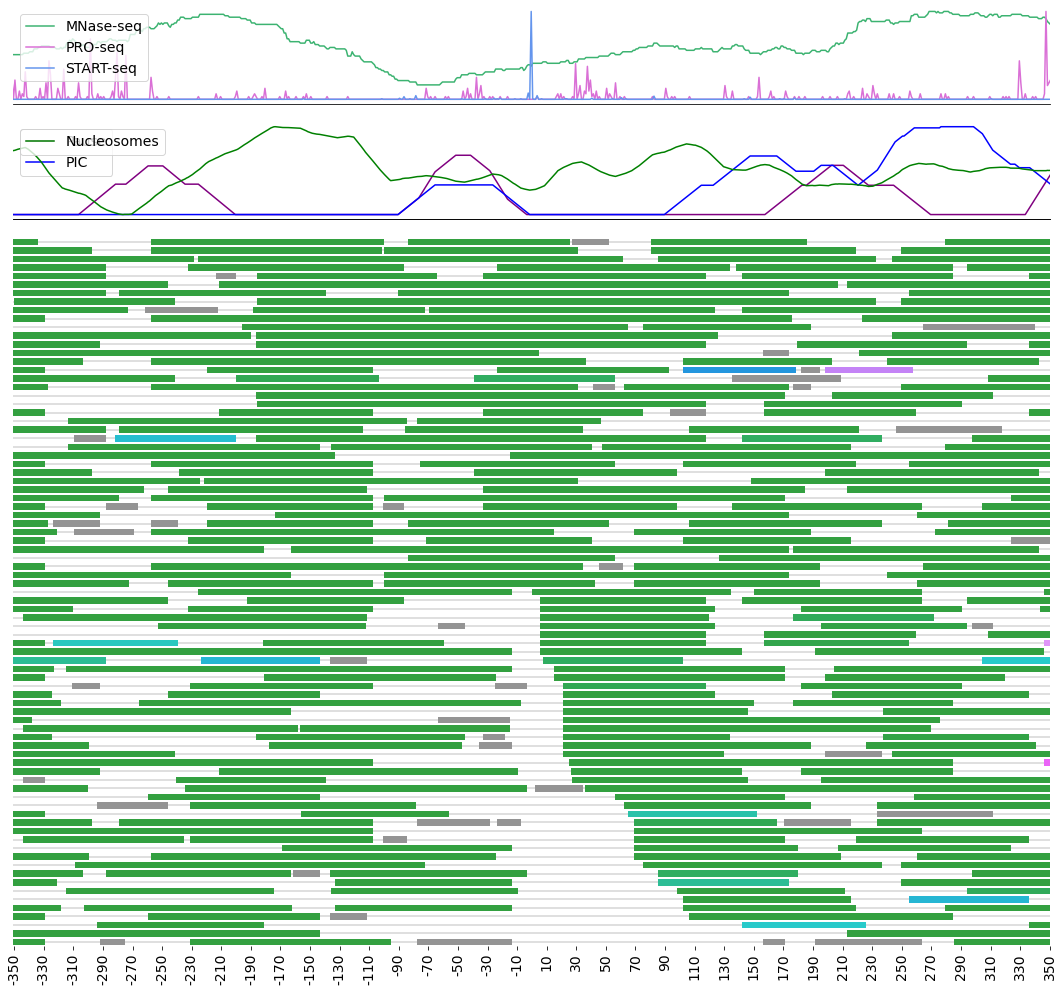

In [65]:
# a few random example enhancers-- I generated these plots (with the same script) for all transcribed enhancers

s=-350
e=351
condition='untreated'
gs=gtf_df.loc[gtf_df['PRC_peak']>=100]['gid']
print(len(gs))
smooth=25
count=10

cts=0
for g in gs:
    if g in pro_peaks and g in start_peaks:
        cts+=1
        
        #getting all the gene Fiber-seq data together into a temporary dataframe
        #for enhancers, print out the genomic positions since they don't have a gid 
        print(g, gtf_df.loc[gtf_df['gid']==g]['chrom']+':'+str(gtf_df.loc[gtf_df['gid']==g]['TSS'].tolist()[0]), gtf_df.loc[gtf_df['gid']==g]['strand'])
        genes_tmp=genes_df.loc[(genes_df['condition']=='untreated')&(genes_df['gid']==g)].reset_index()
        genes_tmp['d']=dist_to_fp(genes_tmp,gtf_df,0,300,81,100000)['d']
        genes_tmp=genes_tmp.dropna(subset='d')
        genes_tmp=genes_tmp.sort_values(by='d')
        d=genes_tmp.drop(['dataset','condition', 'gid','d'], axis=1).fillna(0)[np.arange(s,e).astype(str)]
        rows=d.shape[0]

        #generating a mask to "grey" unknown footprints
        
        #makes a unique number id for each footprint that is not a nucleosome to start
        d2=d.copy()
        d2=d2.mask(d2>=80,0)
        d2=d2.mask(d2<=10,0)
        id_df=[]
        idc=[]
        k=1
        for index, row in d2.iterrows():
            r_tmp=np.zeros(len(row))
            row=row.to_numpy()
            a=np.where(row!=0)[0]
            b=np.append(a,[0])
            a=np.append([0],a)
            c=b-a
            c=c[:-1]
            f=np.where(c!=1)[0]
            f=a[f+1]
            for h in f:
                r_tmp[h:h+int(row[h])]+=k
                k+=1
            id_df.append(r_tmp)
            idc.append(index)
        
        #blocks footprints that are not "hits," aka small footprints not overlapping START/PRO-seq
        id_df=pd.DataFrame(id_df)
        id_df.index=idc
        id_df.columns=d.columns
        a=d.loc[d[pro_peaks[g].astype(str)].isin(np.arange(40,60)).any(axis=1)]  
        b=d.loc[d[start_peaks[g].astype(str)].isin(np.arange(61,80)).any(axis=1)]  
        hits=np.unique(id_df.loc[a.index,pro_peaks[g].astype(str)].to_numpy()).tolist()+np.unique(id_df.loc[b.index,start_peaks[g].astype(str)].to_numpy()).tolist()
        id_df=id_df.mask(id_df.isin(hits), 0)

        #adding auxiliary tracks from MNAse etc.
        mnase_fwd = signal_df.loc[signal_df['dataset']=='mnase_15']
        mnase_fwd=mnase_fwd.loc[mnase_fwd['pos'].isin(np.arange(s-100,e+100))]
        mnase_fwd=mnase_fwd.loc[:,g]

        PRO_fwd = signal_df.loc[(signal_df['dataset']=='PRO_fwd')&(signal_df['pos'].isin(np.arange(s-100,e+100)))].loc[:,g]
        PRC_fwd = signal_df.loc[(signal_df['dataset']=='START_fwd')&(signal_df['pos'].isin(np.arange(s-100,e+100)))].loc[:,g]
        PRO_rev = signal_df.loc[(signal_df['dataset']=='PRO_rev')&(signal_df['pos'].isin(np.arange(s-100,e+100)))].loc[:,g]
        PRC_rev = signal_df.loc[(signal_df['dataset']=='START_rev')&(signal_df['pos'].isin(np.arange(s-100,e+100)))].loc[:,g]
        
        #plotting full browser track
        fig, ax=plt.subplots(3,1, figsize=(15,rows//7+3),gridspec_kw={'height_ratios': [1.5,1.5,rows//7]})

        #Fiber-seq metaprofile
        a=meta_line_plot(genes_tmp,  s-smooth-100, e+smooth+100, 90,100000, False)
        b=meta_line_plot(genes_tmp,  s-smooth-100, e+smooth+100, 40, 60, False)
        c=meta_line_plot(genes_tmp,  s-smooth-100, e+smooth+100, 60, 80, False)

        #smooth metaprofile
        box = np.ones(smooth)/smooth
        a = np.convolve(a, box, mode='same')
        a = a[smooth:len(a)-smooth]
        b = np.convolve(b, box, mode='same')
        b = b[smooth:len(b)-smooth]
        c = np.convolve(c, box, mode='same')
        c = c[smooth:len(c)-smooth]

        ax[1].plot(np.arange(s-100,e+100),b, color='purple', label='Pause')
        ax[1].plot(np.arange(s-100,e+100),c, color='blue', label='PIC')
        ax[1].set_xlim(s,e)

        #plot orthogonal data
        ax2 = ax[1].twinx() 
        ax2.plot(np.arange(s-100,e+100),a, color='green',label='Nucleosomes')
        ax2.set_xlim(s,e)
        ax[0].plot(np.arange(s-100,e+100),mnase_fwd/max(mnase_fwd), label='MNase-seq', color='mediumseagreen')
        ax[0].plot(np.arange(s-100,e+100),PRO_fwd/max(PRO_fwd), label='PRO-seq', color='orchid')
        ax[0].plot(np.arange(s-100,e+100),PRC_fwd/max(PRC_fwd), label='START-seq', color='cornflowerblue')

        ax[0].set_xlim(s,e)
        ax[0].legend(loc='upper left', ncol=1)
        ax[0].set_xticks([])
        ax[0].set_yticks([])
        ax[0].spines['top'].set_visible(False)
        ax[0].spines['right'].set_visible(False)
        ax[0].spines['left'].set_visible(False)

        ax[1].set_xlim(s,e)
        ax[1].legend(loc='upper left', ncol=1)
        ax[1].set_xticks([])
        ax[1].set_yticks([])
        ax[1].spines['top'].set_visible(False)
        ax[1].spines['right'].set_visible(False)
        ax[1].spines['left'].set_visible(False)
        
        ax2.set_xlim(s,e)
        ax2.legend(loc='upper left', ncol=1)
        ax2.set_xticks([])
        ax2.set_yticks([])
        ax2.spines['top'].set_visible(False)
        ax2.spines['right'].set_visible(False)
        ax2.spines['left'].set_visible(False)


        #generate Fiber-seq read plot
        #background array of lines for accessible
        for i in range(d.shape[0]+1):
            ax[2].axhline(i+.5, color='black', lw=.25, zorder=1)
        #array of white lines to separate reads
        for i in range(d.shape[0]+1):
            ax[2].axhline(i, color='white', lw=2, zorder=3)
            
        #plot masked footprint layer
        sns.heatmap(data=id_df,cmap=mask_cp,vmin=0, vmax=1000, yticklabels=False, cbar=False, ax=ax[2], xticklabels=20,rasterized=True, zorder=3)
        #plot unmasked footprint layer
        sns.heatmap(data=d, cmap=pol_cp,vmin=0, vmax=100, yticklabels=False, cbar=False, ax=ax[2], xticklabels=20,rasterized=True, zorder=2)
        
        plt.tight_layout()
        #plt.savefig('Paper Figures Updated/Figure 3/eRNAs_START/example loci/100+/'+g+'_'+str(s)+'-'+str(e)+'.pdf')#,transparent=True)
        #plt.savefig('Paper Figures Updated/Figure 3/eRNAs_START/example loci/100+/'+g+'_'+str(s)+'-'+str(e)+'.png')#,transparent=True)
        plt.show()
        plt.close()
    if cts==count:
        break

# Coordination between nearby Pol II promoters

In [74]:
genes_df = import_data(['untreated'], '_coding', -200, 200)

2000-2000_coding_untreated_1.tsv
2000-2000_coding_untreated_2.tsv
2000-2000_coding_untreated_3.tsv
2000-2000_coding_untreated_4.tsv
2000-2000_coding_untreated_5.tsv
2000-2000_coding_untreated_6.tsv
2000-2000_coding_untreated_7.tsv


## NDRs

In [22]:
s=-200
e=200

start=-20
end=20
min_size=90
max_size=10000
ndr_reads=genes_df.loc[(genes_df['condition']=='untreated')&(~genes_df.loc[:,np.arange(start,end).astype(str)].isin(np.arange(min_size,max_size)).any(axis=1))]
ndr_reads['rid,gid']=ndr_reads['rid']+','+ndr_reads['gid']
genes_df['rid,gid']=genes_df['rid']+','+genes_df['gid']

print(ndr_reads.shape[0])
ndr_reads=ndr_reads.groupby('gid')['rid'].apply(list).to_dict()
all_reads=genes_df.groupby('gid')['rid'].apply(list).to_dict()

1190339


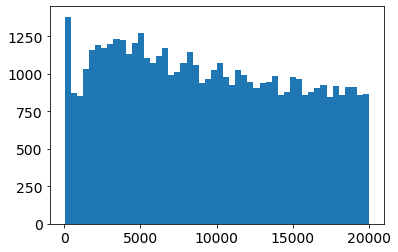

In [42]:
#identify proximal gene TSSs
g_dic = {}
d_dic = {}
gtf_df=pd.read_csv('Reference Files/dm6/dm6_info.csv', sep='\t')
all_dists=[]
for chrom in gtf_df['chrom'].unique():
    g=gtf_df.loc[(gtf_df['chrom']==chrom)&(gtf_df['biotype']=='protein_coding')]
    a=g['TSS'].to_numpy()
    gids=g['gid'].to_numpy()
    b=a-np.array([a]).T
    c=np.where((b<20000)&(b>50))
    all_dists+=b[c].tolist()
    for i,j in zip(gids[c[0]],gids[c[1]]):
        g_dic.setdefault(i, []).append(j)
    for i,j in zip(gids[c[0]],b[c]):
        d_dic.setdefault(i, []).append(j)

gtf_df['nearby_TSS']=gtf_df['gid'].map(g_dic)
gtf_df['nearby_TSS_dist']=gtf_df['gid'].map(d_dic)
plt.hist(all_dists, bins=50)
plt.show()


In [43]:
#count coaccessibility
p_values=[]
yyt=[]
ynt=[]
nyt=[]
nnt=[]
dists=[]
strands=[]
diffs=[]
g1s=[]
g2s=[]

l=0
k=0
for index, row in gtf_df.loc[~gtf_df['nearby_TSS'].isna()].iterrows():
    s1=row['strand']
    g1=row['gid']
    
    if g1 in all_reads:

        for g2 in row['nearby_TSS']:
            
            if g2 in all_reads:
                s2 = gtf_df.loc[gtf_df['gid']==g2]['strand'].to_list()[0]       
                dist = row['nearby_TSS_dist'][k]

                r1 = np.array(all_reads[g1])
                r2 = np.array(all_reads[g2])

                reads=np.intersect1d(r1,r2)
                
                if g1 in ndr_reads:
                    txn1=np.array(ndr_reads[g1])
                else:
                    txn1=np.array([])
                if g2 in ndr_reads:
                    txn2=np.array(ndr_reads[g2])
                else:
                    txn2=np.array([])

                y1=np.intersect1d(txn1, reads)
                y2=np.intersect1d(txn2, reads)
                
                n1=np.setxor1d(reads, y1)
                n2=np.setxor1d(reads, y2)

                yy=np.intersect1d(y1, y2)
                yn=np.intersect1d(y1, n2)
                ny=np.intersect1d(n1, y2)
                nn=np.intersect1d(n1, n2)

                yyt.append(len(yy))
                nyt.append(len(ny))
                ynt.append(len(yn))
                nnt.append(len(nn))
                
                dist=gtf_df.loc[gtf_df['gid']==g1]['TSS'].tolist()[0]-gtf_df.loc[gtf_df['gid']==g2]['TSS'].tolist()[0]
                dists.append(gtf_df.loc[gtf_df['gid']==g1]['TSS'].tolist()[0]-gtf_df.loc[gtf_df['gid']==g2]['TSS'].tolist()[0])
                g1s.append(g1)
                g2s.append(g2)

                if s1==s2 and dist != 0:
                    strands.append('u')                 
                elif s1 == '+' and s2 == '-' and dist != 0:
                    strands.append('c')
                elif  s1 == '-' and s2 == '+' and dist != 0:
                    strands.append('d')
                else:
                    strands.append('X')
    l+=1
    if l%2000==0:
        print(l)
   # print(l)

t=pd.DataFrame()
t['yy']=yyt
t['ny']=nyt
t['yn']=ynt
t['nn']=nnt
t['strand']=strands
t['dists']=dists
t['g1']=g1s
t['g2']=g2s
t=t.loc[t['strand']!='X']


2000
4000
6000
8000
10000
12000


[[128624, 24368], [26428, 47557]]
100
SignificanceResult(statistic=9.498439869729681, pvalue=0.0)
[[59935, 23133], [23382, 40427]]
500
SignificanceResult(statistic=4.479591481617072, pvalue=0.0)
[[166962, 126108], [121317, 258027]]
1000
SignificanceResult(statistic=2.815908190697776, pvalue=0.0)
[[273485, 215489], [213294, 313225]]
2500
SignificanceResult(statistic=1.8637436836537504, pvalue=0.0)
[[204986, 174566], [171910, 232514]]
5000
SignificanceResult(statistic=1.5882267538190942, pvalue=0.0)
[[157525, 133633], [130256, 136203]]
7500
SignificanceResult(statistic=1.2326072166049955, pvalue=0.0)
[[203525, 144876], [145416, 123807]]
10000
SignificanceResult(statistic=1.1960637352770553, pvalue=2.2976989195760037e-262)
   distance  odds ratio        p value
0     500.0    9.498440   0.000000e+00
1    1000.0    4.479591   0.000000e+00
2    2500.0    2.815908   0.000000e+00
3    5000.0    1.863744   0.000000e+00
4    7500.0    1.588227   0.000000e+00
5   10000.0    1.232607   0.000000e+

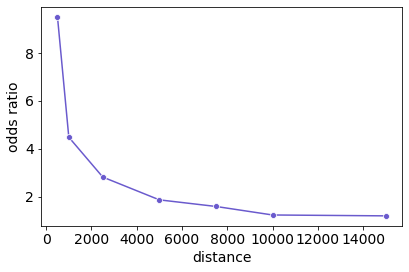

In [48]:
#binned
d=[100,500,1000,2500,5000,7500,10000,15000]

pss=[]
statss=[]
for i in range(len(d)-1):

    tmp1=t.loc[(t['abs_dists']>=d[i])&(t['abs_dists']<d[i+1])]
    tests=[]
    tmp=tmp1.dropna()
    tmp['y1']=tmp['yn']+tmp['yy']
    tmp['y2']=tmp['ny']+tmp['yy']
    #tmp=tmp.loc[tmp['strand']=='c']
    a=tmp.sum(axis=0)
    table=[[a['yy'],a['yn']],[a['ny'],a['nn']]]
    print(table)
    print(d[i])
    print(scipy.stats.fisher_exact(table))
    pss.append(scipy.stats.fisher_exact(table)[1])
    statss.append((scipy.stats.fisher_exact(table)[0]))
    
    
ts=pd.DataFrame([d[1:],statss,pss]).T
ts.columns=['distance','odds ratio','p value']

print(ts)
plt.figure(figsize=(6,4))
ax=sns.lineplot(data=ts, x='distance',y='odds ratio', color='slateblue', marker='o')
#plt.ylim(1,3.5)
plt.tight_layout()
plt.savefig('Paper Figures Updated/Figure 3/coordination/NDR/all.pdf')
plt.savefig('Paper Figures Updated/Figure 3/coordination/NDR/all.png')
plt.show()



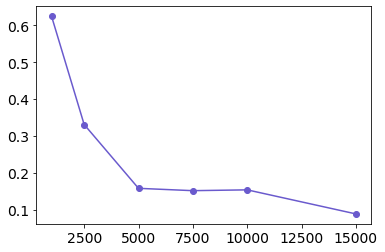

In [49]:
#per locus
t['abs_dists']=np.abs(t['dists'])
d=[100,1000,2500,5000,7500,10000,15000]

t_d=pd.DataFrame()
pfrac=[]
pss=[]
statss=[]

for i in range(len(d)-1):

    tmp1=t.loc[(t['abs_dists']>=d[i])&(t['abs_dists']<d[i+1])]#&(t['strand']=='b')]
    tests=[]
    tmp=tmp1.dropna()
    tmp['y1']=tmp['yn']+tmp['yy']
    tmp['y2']=tmp['ny']+tmp['yy']
    a=tmp.sum(axis=0)
    ps=[]
    for index, row in tmp.iterrows():
        table=[[row['yy'],row['yn']],[row['ny'],row['nn']]]
        ps.append(scipy.stats.fisher_exact(table)[1])

            
    tmp['p']=ps
    if i<10:
        for k in [
            1
        ]:
            tmp1=tmp.loc[(tmp['y1']>k)&(tmp['y2']>k)]
            pfrac.append(tmp1.loc[tmp1['p']<=.1].shape[0]/tmp1.shape[0])
    
ts=pd.DataFrame([d[1:],statss,pss]).T
ts.columns=['distance','odds ratio','p value']


plt.figure(figsize=(6,4))
plt.plot(d[1:],pfrac[:], label=str(i)+' min txn reads', color='slateblue', marker='o')
plt.savefig('Paper Figures Updated/Figure 3/coordination/NDR/frac.pdf')
plt.savefig('Paper Figures Updated/Figure 3/coordination/NDR/frac.png')
plt.show()

## PPP + PIC

In [75]:
s=-200
e=200

start=-20
end=20
min_size=90
max_size=10000
#call_peaks(signal_df, gtf_df, dataset, min_pos, max_pos, window_size, min_threshold,min_cov,plot):


print('ndr reads')
ndr_reads=genes_df.loc[(genes_df['condition']=='untreated')&(~genes_df.loc[:,np.arange(start,end).astype(str)].isin(np.arange(min_size,max_size)).any(axis=1))]
ndr_reads=ndr_reads.drop(['dataset'], axis=1).fillna(0)
print('peaks')
pro_peaks=call_peaks(signal_df, gtf_df, 'PRO_fwd', 0, 100, 20, 10, 20, 0)
cage_peaks=call_peaks(signal_df, gtf_df, 'CAGE_fwd', -50, 50, 20, 10,20, 0)
ndr_reads['rid,gid']=ndr_reads['rid']+','+ndr_reads['gid']


print('hits pause')
hits_pause, nohits_pause=call_hits(ndr_reads, 40, 60, 1/.15, pro_peaks, s)
print(len(hits_pause), len(nohits_pause))
pause_reads=ndr_reads.loc[ndr_reads['rid,gid'].isin(hits_pause)]

print('hits pic')
hits_pic, nohits_pic=call_hits(ndr_reads, 61, 80, 1/.15, cage_peaks, s)
print(len(hits_pic), len(nohits_pic))
pic_reads=ndr_reads.loc[ndr_reads['rid,gid'].isin(hits_pic)]

print('nopic')
no_pic_pause=np.intersect1d(np.array(nohits_pause), np.array(nohits_pic))
no_pic_pause=ndr_reads.loc[ndr_reads['rid,gid'].isin(no_pic_pause)]

no_pic_pause=no_pic_pause[['rid','gid', 'rid,gid']]
pic_reads=pic_reads[['rid','gid', 'rid,gid']]
pause_reads=pause_reads[['rid','gid', 'rid,gid']]
ndr_reads=ndr_reads[['rid','gid', 'rid,gid']]
pp_reads=ndr_reads.loc[(ndr_reads['rid,gid'].isin(pause_reads['rid,gid']))|(ndr_reads['rid,gid'].isin(pic_reads['rid,gid']))]

pause_reads=pause_reads.groupby('gid')['rid'].apply(list).to_dict()
pic_reads=pic_reads.groupby('gid')['rid'].apply(list).to_dict()
ndr_reads=ndr_reads.groupby('gid')['rid'].apply(list).to_dict()
pp_reads=pp_reads.groupby('gid')['rid'].apply(list).to_dict()
no_pic_pause=no_pic_pause.groupby('gid')['rid'].apply(list).to_dict()



ndr reads
peaks
hits pause
1000000
12270 1178069
hits pic
1000000
10396 1179943
nopic


In [76]:
#identify proximal gene TSSs
g_dic = {}
d_dic = {}
gtf_df=pd.read_csv('Reference Files/dm6/dm6_info.csv', sep='\t')
all_dists=[]
for chrom in gtf_df['chrom'].unique():
    g=gtf_df.loc[(gtf_df['chrom']==chrom)&(gtf_df['biotype']=='protein_coding')]
    a=g['TSS'].to_numpy()
    gids=g['gid'].to_numpy()
    b=a-np.array([a]).T
    c=np.where((b<20000)&(b>100))
    all_dists+=b[c].tolist()
    for i,j in zip(gids[c[0]],gids[c[1]]):
        g_dic.setdefault(i, []).append(j)
    for i,j in zip(gids[c[0]],b[c]):
        d_dic.setdefault(i, []).append(j)
        
gtf_df['nearby_TSS']=gtf_df['gid'].map(g_dic)
gtf_df['nearby_TSS_dist']=gtf_df['gid'].map(d_dic)

In [77]:
p_values=[]
yyt=[]
ynt=[]
nyt=[]
nnt=[]
dists=[]
strands=[]
diffs=[]
g1s=[]
g2s=[]

l=0
k=0
for index, row in gtf_df.loc[~gtf_df['nearby_TSS'].isna()].iterrows():
    s1=row['strand']
    g1=row['gid']
    
    if g1 in pp_reads:

        for g2 in row['nearby_TSS']:
            
            if g2 in pp_reads:
                s2 = gtf_df.loc[gtf_df['gid']==g2]['strand'].to_list()[0]       
                dist = row['nearby_TSS_dist'][k]

                r1 = np.array(ndr_reads[g1])
                r2 = np.array(ndr_reads[g2])

                reads=np.intersect1d(r1,r2)
                if g1 in pause_reads:
                    pause1=np.array(pause_reads[g1])
                else:
                    pause1=np.array([])
                if g2 in pause_reads:
                    pause2=np.array(pause_reads[g2])
                else:
                    pause2=np.array([])
                
                if g1 in pic_reads:
                    pic1=np.array(pic_reads[g1])
                else:
                    pic1=np.array([])
                if g2 in pic_reads:
                    pic2=np.array(pic_reads[g2])
                else:
                    pic2=np.array([])
                    
                pause1=np.intersect1d(pause1, reads)
                pause2=np.intersect1d(pause2, reads)

                pic1=np.intersect1d(pic1, reads)
               
                pic2=np.intersect1d(pic2, reads)
                
                y1=np.unique(np.append(pause1,pic1))
                y2=np.unique(np.append(pause2,pic2))

                n1=np.setxor1d(reads, y1)
                n2=np.setxor1d(reads, y2)

                yy=np.intersect1d(y1, y2)
                yn=np.intersect1d(y1, n2)
                ny=np.intersect1d(n1, y2)
                nn=np.intersect1d(n1, n2)

                yyt.append(len(yy))
                nyt.append(len(ny))
                ynt.append(len(yn))
                nnt.append(len(nn))
                dist=gtf_df.loc[gtf_df['gid']==g1]['TSS'].tolist()[0]-gtf_df.loc[gtf_df['gid']==g2]['TSS'].tolist()[0]
                dists.append(gtf_df.loc[gtf_df['gid']==g1]['TSS'].tolist()[0]-gtf_df.loc[gtf_df['gid']==g2]['TSS'].tolist()[0])
                g1s.append(g1)
                g2s.append(g2)

              #  print(g1, g2, gtf_df.loc[gtf_df['gid']==g1]['TSS'].tolist()[0], gtf_df.loc[gtf_df['gid']==g2]['TSS'].tolist()[0], gtf_df.loc[gtf_df['gid']==g1]['TSS'].tolist()[0]-gtf_df.loc[gtf_df['gid']==g2]['TSS'].tolist()[0], dist)

                if s1==s2 and dist != 0:
                    strands.append('u')                 
                elif s1 == '+' and s2 == '-' and dist != 0:
                    strands.append('c')
                elif  s1 == '-' and s2 == '+' and dist != 0:
                    strands.append('d')
                else:
                    strands.append('X')
    l+=1
    if l%2000==0:
        print(l)

tc=pd.DataFrame()
tc['yy']=yyt
tc['ny']=nyt
tc['yn']=ynt
tc['nn']=nnt
tc['strand']=strands
tc['dists']=dists
tc['g1']=g1s
tc['g2']=g2s
tc['type']='p-p'
tc['abs_dists']=np.abs(tc['dists'])
tc=tc.loc[tc['strand']!='X']


2000
4000
6000
8000
10000
12000


[[71, 1033], [1174, 48070]]
100
SignificanceResult(statistic=2.814258927290388, pvalue=4.466926333660599e-13)
[[77, 800], [778, 20024]]
500
SignificanceResult(statistic=2.477262210796915, pvalue=5.993846542594457e-11)
[[113, 1712], [1542, 44722]]
1000
SignificanceResult(statistic=1.9143067323660254, pvalue=2.5824314861059736e-09)
[[179, 3374], [3139, 82305]]
2500
SignificanceResult(statistic=1.3910503705698412, pvalue=5.5813603968554174e-05)
[[129, 2325], [2298, 57826]]
5000
SignificanceResult(statistic=1.3961750751003679, pvalue=0.0005167895005781301)
[[59, 1458], [1424, 40337]]
7500
SignificanceResult(statistic=1.146273080717005, pvalue=0.313995640093578)
[[53, 1691], [1575, 52488]]
10000
SignificanceResult(statistic=1.0445078989608854, pvalue=0.7180148936003372)


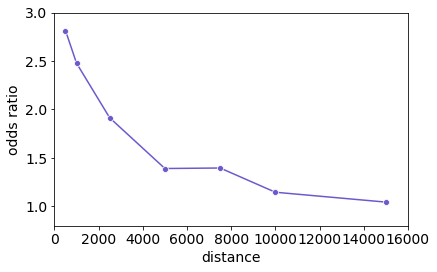

In [80]:
d=[100,500,1000,2500,5000,7500,10000,15000]

t_d=pd.DataFrame()
pss=[]
statss=[]
for i in range(len(d)-1):

    tmp=tc.loc[(tc['abs_dists']>=d[i])&(tc['abs_dists']<d[i+1])]
    tests=[]
    tmp['y1']=tmp['yn']+tmp['yy']
    tmp['y2']=tmp['ny']+tmp['yy']
   # tmp=tmp.loc[tmp['strand']=='d']
    a=tmp.sum(axis=0)
    ps=[]
    for index, row in tmp.iterrows():
        table=[[row['yy'],row['yn']],[row['ny'],row['nn']]]
        ps.append(scipy.stats.fisher_exact(table)[1])

    tmp['p']=ps
    table=[[a['yy'],a['yn']],[a['ny'],a['nn']]]
    print(table)
    print(d[i])
    print(scipy.stats.fisher_exact(table))
    pss.append(np.log10(scipy.stats.fisher_exact(table)[1]))
    statss.append((scipy.stats.fisher_exact(table)[0]))
    
    
ts1=pd.DataFrame([np.array(d[1:]),statss,pss]).T
ts1.columns=['distance','odds ratio','p value']


plt.figure(figsize=(6,4))
sns.lineplot(data=ts1, x='distance',y='odds ratio', color='slateblue', marker='o')
plt.ylim(.8, 3)
plt.xlim(0,16000)

plt.tight_layout()

plt.savefig('Paper Figures Updated/Figure 3/coordination/PPP+PIC/all.png')
plt.savefig('Paper Figures Updated/Figure 3/coordination/PPP+PIC/all.pdf')
plt.show()

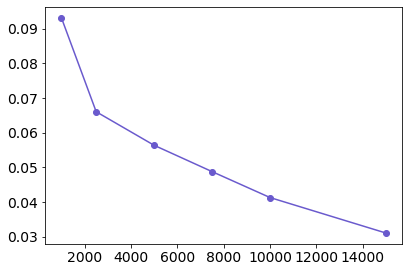

In [81]:
d=[100,1000,2500,5000,7500,10000,15000]


t_d=pd.DataFrame()
pfrac=[]
pss=[]
statss=[]

for i in range(len(d)-1):

    tmp1=tc.loc[(tc['abs_dists']>=d[i])&(tc['abs_dists']<d[i+1])]
    tests=[]
    tmp=tmp1.dropna()
    tmp['y1']=tmp['yn']+tmp['yy']
    tmp['y2']=tmp['ny']+tmp['yy']

    a=tmp.sum(axis=0)
    ps=[]
    for index, row in tmp.iterrows():
        table=[[row['yy'],row['yn']],[row['ny'],row['nn']]]
        ps.append(scipy.stats.fisher_exact(table)[1])

    tmp['p']=ps
    for k in [0]:
        tmp1=tmp.loc[(tmp['y1']>k)&(tmp['y2']>k)]
        pfrac.append(tmp1.loc[tmp1['p']<=.1].shape[0]/tmp1.shape[0])
    
    
ts=pd.DataFrame([d[1:],statss,pss]).T
ts.columns=['distance','odds ratio','p value']


plt.figure(figsize=(6,4))
plt.plot(d[1:],pfrac[:], label=str(i)+' min txn reads', color='slateblue', marker='o')

plt.tight_layout()
plt.savefig('Paper Figures Updated/Figure 3/coordination/PPP+PIC/fraction_sig.pdf')
plt.savefig('Paper Figures Updated/Figure 3/coordination/PPP+PIC/fraction_sig.png')
plt.show()

## Enhancer-Promoter

In [36]:
def call_peaks(signal_df, gtf_df, dataset, min_pos, max_pos, window_size, min_threshold,min_cov,plot):
    signal=signal_df.loc[(signal_df['dataset']==dataset)&(signal_df['pos'].isin(np.arange(min_pos, max_pos)))]
    peak_dic={}
    
    k=0
    for gene in gtf_df.loc[gtf_df['biotype'].isin(['protein_coding','enhancer'])]['gid']:
        #print(signal[gene])
        maxes=[]
        min_peak = np.amax(signal[gene].to_numpy())/min_threshold
        for i in range(max_pos-min_pos):
            window=signal[gene].to_numpy()[i:i+window_size]
            if np.amax(window)>min_cov and np.amax(window)>min_peak:
                maxes.append(np.argmax(window)+i+min_pos)
                
        maxes=np.unique(np.array(maxes))
        if len(maxes)>0:
            peak_dic[gene]=maxes

        k+=1
    return peak_dic

def call_footprint_peaks(genes_df, peak_dic, signal_df, min_size, max_size, s,e, plot, outdir):
    
    i=0
    peak_df=pd.DataFrame()
    no_peak_df=pd.DataFrame()

    
    for gene in peak_dic.keys():
        genes_tmp=genes_df.loc[genes_df['gid']==gene]
        if genes_tmp.shape[0]>0:
            peaks=np.array(peak_dic[gene]).astype(str)
            tmp=genes_tmp.loc[genes_tmp[peaks].isin(np.arange(min_size,max_size)).any(axis=1)]
            c = np.setxor1d(tmp.index.to_numpy(), genes_tmp.index.to_numpy())
            no_tmp=genes_tmp.loc[c]

            if tmp.shape[0]>0:


                peak_df=pd.concat([peak_df, tmp])

        i+=1
        if i%3000==0:
            print(i)
    return peak_df

def stratified_sample(g1,g2):
    g1_ss=pd.DataFrame()
    g2_ss=pd.DataFrame()
    for gene in np.intersect1d(g1['gid'].to_numpy(), g2['gid'].to_numpy()):
        g1_g=g1.loc[g1['gid']==gene]
        g2_g=g2.loc[g2['gid']==gene]
        min_len=min([g1_g.shape[0], g2_g.shape[0]])
        g1_g=g1_g.sample(n=min_len, replace=False)
        g2_g=g2_g.sample(n=min_len, replace=False)
        g1_ss=pd.concat([g1_ss, g1_g])
        g2_ss=pd.concat([g2_ss, g2_g])
    return g1_ss, g2_ss

In [100]:
gtf_df=pd.read_csv('Reference Files/dm6/dm6_info_eRNA_gid.csv', sep='\t')
gtf_df=gtf_df.drop_duplicates(subset='TSS', keep='first')
signal_df=pd.read_parquet('Reference Files/dm6/signal/signal_info_enhancer_TSS_START.pq').drop(['dataset','pos'], axis=1)
signal_df=pd.concat([signal_df, pd.read_parquet('Reference Files/dm6/signal/signal_info_protein_coding_TSS_START.pq')],axis=1)

<ipython-input-100-756de3ceccb2>:1: DtypeWarning: Columns (34) have mixed types. Specify dtype option on import or set low_memory=False.
  gtf_df=pd.read_csv('Reference Files/dm6/dm6_info_eRNA_gid.csv', sep='\t')


In [38]:
#import new data (processed, coding)
s=-200
e=200

genes_df=pd.DataFrame()
for f in os.listdir('HMM_footprint_caller-v2/Pol-II_dm6/Processed/enhancers/'):
    if 'untreated' in f and 'enhancers' in f:
        print(f)
        tmp=pd.read_csv('HMM_footprint_caller-v2/Pol-II_dm6/Processed/enhancers/'+f, sep='\t', usecols=np.append(['gid','rid','condition','dataset'],np.arange(s,e).astype(str)))#, nrows=3)
        genes_df=pd.concat([tmp, genes_df], axis=0)
genes_df=genes_df[genes_df.columns[::-1]]
genes_df.columns=['condition','rid','gid','dataset']+np.arange(-200,200).astype(str).tolist()
genes_df=genes_df[np.arange(-200,200).astype(str).tolist()+['dataset','gid','rid','condition']]

for f in os.listdir('HMM_footprint_caller-v2/Pol-II_dm6/Processed/'):
    if 'untreated' in f and '_coding' in f and 'zip' not in f:
        print(f)
        tmp=pd.read_csv('HMM_footprint_caller-v2/Pol-II_dm6/Processed/'+f, sep='\t', usecols=np.append(['gid','rid','condition','dataset'],np.arange(s,e).astype(str)))#, nrows=3)
        genes_df=pd.concat([tmp, genes_df], axis=0)

genes_df.columns=genes_df.columns.astype(str)

enhancers_start_untreated_1.tsv
enhancers_start_untreated_2.tsv
enhancers_start_untreated_3.tsv
enhancers_start_untreated_4.tsv
enhancers_start_untreated_5.tsv
enhancers_start_untreated_6.tsv
enhancers_start_untreated_7.tsv
2000-2000_coding_untreated_1.tsv
2000-2000_coding_untreated_2.tsv
2000-2000_coding_untreated_3.tsv
2000-2000_coding_untreated_4.tsv
2000-2000_coding_untreated_5.tsv
2000-2000_coding_untreated_6.tsv
2000-2000_coding_untreated_7.tsv


In [44]:
s=-200
e=200

start=-20
end=20
min_size=90
max_size=10000
# call_peaks(signal_df, gtf_df, dataset, min_pos, max_pos, window_size, min_threshold,min_cov,plot):W


print('ndr reads')
ndr_reads=genes_df.loc[(genes_df['condition']=='untreated')&(~genes_df.loc[:,np.arange(start,end).astype(str)].isin(np.arange(min_size,max_size)).any(axis=1))]
print(ndr_reads.shape)

#genes_df=[]
ndr_reads=ndr_reads.drop(['dataset'], axis=1).fillna(0)
print('peaks')
pro_peaks=call_peaks(signal_df, gtf_df, 'PRO_fwd', 0, 100, 20, 10, 5, 0)
cage_peaks=call_peaks(signal_df, gtf_df, 'START_fwd', -50, 50, 20, 10, 5, 0)
ndr_reads['rid,gid']=ndr_reads['rid']+','+ndr_reads['gid']


print('hits pause')
hits_pause, nohits_pause=call_hits(ndr_reads, 40, 60, 1/.15, pro_peaks, s)
print(len(hits_pause), len(nohits_pause))
pause_reads=ndr_reads.loc[ndr_reads['rid,gid'].isin(hits_pause)]

print('hits pic')
hits_pic, nohits_pic=call_hits(ndr_reads, 61, 80, 1/.15, cage_peaks, s)
print(len(hits_pic), len(nohits_pic))
pic_reads=ndr_reads.loc[ndr_reads['rid,gid'].isin(hits_pic)]

print('nopic')
no_pic_pause=np.intersect1d(np.array(nohits_pause), np.array(nohits_pic))
no_pic_pause=ndr_reads.loc[ndr_reads['rid,gid'].isin(no_pic_pause)]

no_pic_pause=no_pic_pause[['rid','gid', 'rid,gid']]
pic_reads=pic_reads[['rid','gid', 'rid,gid']]
pause_reads=pause_reads[['rid','gid', 'rid,gid']]
ndr_reads=ndr_reads[['rid','gid', 'rid,gid']]
pp_reads=ndr_reads.loc[(ndr_reads['rid,gid'].isin(pause_reads['rid,gid']))|(ndr_reads['rid,gid'].isin(pic_reads['rid,gid']))]

pause_reads=pause_reads.groupby('gid')['rid'].apply(list).to_dict()
pic_reads=pic_reads.groupby('gid')['rid'].apply(list).to_dict()
ndr_reads=ndr_reads.groupby('gid')['rid'].apply(list).to_dict()
pp_reads=pp_reads.groupby('gid')['rid'].apply(list).to_dict()
no_pic_pause=no_pic_pause.groupby('gid')['rid'].apply(list).to_dict()



ndr reads
(1631320, 404)
peaks
hits pause
1000000
17790 1613530
hits pic
1000000
16274 1615046
nopic


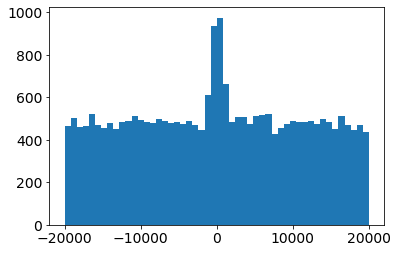

In [45]:
#identify proximal gene and tRNA TSSs
g_dic = {}
d_dic = {}

mrnas=gtf_df.loc[gtf_df['biotype']=='protein_coding']
ernas=gtf_df.loc[gtf_df['biotype']=='enhancer']

all_dists=[]
for chrom in mrnas['chrom'].unique():
    g1=mrnas.loc[mrnas['chrom']==chrom]
    g2=ernas.loc[ernas['chrom']==chrom]
    a1=g1['TSS'].to_numpy()
    a2=g2['TSS'].to_numpy()
    gids1=g1['gid'].to_numpy()
    gids2=g2['gid'].to_numpy()

    b=a1-np.array([a2]).T
    c=np.where((b<20000)&(b>-20000))
    all_dists+=b[c].tolist()
    for i,j in zip(gids1[c[1]],gids2[c[0]]):
        g_dic.setdefault(i, []).append(j)
    for i,j in zip(gids1[c[1]],b[c]):
        d_dic.setdefault(i, []).append(j)

gtf_df['nearby_erna']=gtf_df['gid'].map(g_dic)
gtf_df['nearby_erna_dist']=gtf_df['gid'].map(d_dic)
plt.hist(all_dists, bins=50)
plt.show()

In [46]:
p_values=[]
yyt=[]
ynt=[]
nyt=[]
nnt=[]
dists=[]
strands=[]
diffs=[]
g1s=[]
g2s=[]

l=0
k=0
for index, row in gtf_df.loc[~gtf_df['nearby_erna'].isna()].iterrows():
    s1=row['strand']
    g1=row['gid']
    
    if g1 in ndr_reads:
        #tested=[]
        for g2 in row['nearby_erna']:
            
            if g2 in  ndr_reads:# and g2 not in tested:
                #tested.append(g2)
                s2 = gtf_df.loc[gtf_df['gid']==g2]['strand'].to_list()[0]       
                dist = row['nearby_erna_dist'][k]

                r1 = np.array(ndr_reads[g1])
                r2 = np.array(ndr_reads[g2])

                reads=np.intersect1d(r1,r2)
                if g1 in pause_reads:
                    pause1=np.array(pause_reads[g1])
                else:
                    pause1=np.array([])
                if g2 in pause_reads:
                    pause2=np.array(pause_reads[g2])
                else:
                    pause2=np.array([])
                
                if g1 in pic_reads:
                    pic1=np.array(pic_reads[g1])
                else:
                    pic1=np.array([])
                if g2 in pic_reads:
                    pic2=np.array(pic_reads[g2])
                else:
                    pic2=np.array([])
                    
                pause1=np.intersect1d(pause1, reads)
                pause2=np.intersect1d(pause2, reads)

                pic1=np.intersect1d(pic1, reads)
               
                pic2=np.intersect1d(pic2, reads)
                
                y1=np.unique(np.append(pause1,pic1))
                y2=np.unique(np.append(pause2,pic2))

                n1=np.setxor1d(reads, y1)
                n2=np.setxor1d(reads, y2)

                yy=np.intersect1d(y1, y2)
                yn=np.intersect1d(y1, n2)
                ny=np.intersect1d(n1, y2)
                nn=np.intersect1d(n1, n2)

                yyt.append(len(yy))
                nyt.append(len(ny))
                ynt.append(len(yn))
                nnt.append(len(nn))
                dist=gtf_df.loc[gtf_df['gid']==g1]['TSS'].tolist()[0]-gtf_df.loc[gtf_df['gid']==g2]['TSS'].tolist()[0]
                dists.append(gtf_df.loc[gtf_df['gid']==g1]['TSS'].tolist()[0]-gtf_df.loc[gtf_df['gid']==g2]['TSS'].tolist()[0])
                g1s.append(g1)
                g2s.append(g2)

              #  print(g1, g2, gtf_df.loc[gtf_df['gid']==g1]['TSS'].tolist()[0], gtf_df.loc[gtf_df['gid']==g2]['TSS'].tolist()[0], gtf_df.loc[gtf_df['gid']==g1]['TSS'].tolist()[0]-gtf_df.loc[gtf_df['gid']==g2]['TSS'].tolist()[0], dist)

                if s1==s2 and dist > 0:
                    strands.append('uu')
                elif s1==s2 and dist < 0:
                    strands.append('du')                    
                elif s1 != s2 and dist > 0:
                    strands.append('d')
                elif s1 != s2 and dist < 0:
                    strands.append('c')
    l+=1
    if l%1000==0:
        print(l)
   # print(l)
#t2=t.copy()
te=pd.DataFrame()
te['yy']=yyt
te['ny']=nyt
te['yn']=ynt
te['nn']=nnt
te['strand']=strands
te['dists']=dists
te['g1']=g1s
te['g2']=g2s
te['abs_dists']=np.abs(te['dists'])
te['type']='e-p'


1000
2000
3000
4000
5000
6000
7000
8000


[[89, 2524], [1100, 69288]]
500
SignificanceResult(statistic=2.221089180233396, pvalue=1.3978521202619923e-10)
[[103, 4107], [1575, 84067]]
1000
SignificanceResult(statistic=1.338620628350358, pvalue=0.0060433976918529714)
[[93, 4281], [2125, 96974]]
2500
SignificanceResult(statistic=0.9913661733789522, pvalue=1.0)
[[75, 3493], [1790, 89549]]
5000
SignificanceResult(statistic=1.0741634905885193, pvalue=0.5384624350158744)
[[39, 2208], [1284, 66433]]
7500
SignificanceResult(statistic=0.9138699122985237, pvalue=0.6369223429026543)
[[25, 2159], [1363, 94242]]
10000
SignificanceResult(statistic=0.800637642015865, pvalue=0.3137208719979231)


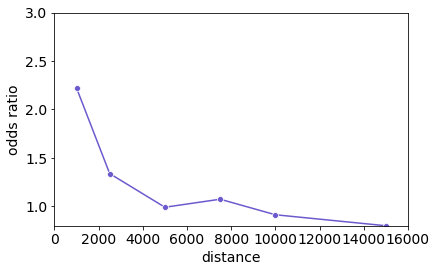

In [82]:
d=[500,1000,2500,5000,7500,10000, 15000]

t_d=pd.DataFrame()
pss=[]
statss=[]
for i in range(len(d)-1):

    tmp=te.loc[(te['abs_dists']>=d[i])&(te['abs_dists']<d[i+1])]
    tests=[]
    tmp['y1']=tmp['yn']+tmp['yy']
    tmp['y2']=tmp['ny']+tmp['yy']
   # tmp=tmp.loc[tmp['strand']=='d']
    a=tmp.sum(axis=0)
    ps=[]
    for index, row in tmp.iterrows():
        table=[[row['yy'],row['yn']],[row['ny'],row['nn']]]
        ps.append(scipy.stats.fisher_exact(table)[1])

    tmp['p']=ps
    table=[[a['yy'],a['yn']],[a['ny'],a['nn']]]
    print(table)
    print(d[i])
    print(scipy.stats.fisher_exact(table))
    pss.append(np.log10(scipy.stats.fisher_exact(table)[1]))
    statss.append((scipy.stats.fisher_exact(table)[0]))
    
    
ts1=pd.DataFrame([np.array(d[1:]),statss,pss]).T
ts1.columns=['distance','odds ratio','p value']


plt.figure(figsize=(6,4))
sns.lineplot(data=ts1, x='distance',y='odds ratio', color='slateblue', marker='o')
plt.ylim(.8, 3)
plt.xlim(0,16000)
plt.tight_layout()
plt.savefig('Paper Figures Updated/Figure 3/coordination/eRNA/all.png')
plt.savefig('Paper Figures Updated/Figure 3/coordination/eRNA/all.pdf')

plt.show()

# TADs and insulators

In [101]:
t_all=pd.concat([te,tc]).reset_index()
#include both sets in analysis

## import info

Empty DataFrame
Columns: [index, yy, ny, yn, nn, strand, dists, g1, g2, abs_dists, type, pr_y, en_y, sum]
Index: []


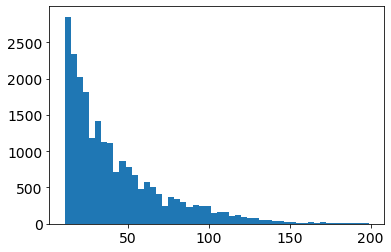

In [102]:
t_all['sum']=t_all['yy']+t_all['yn']+t_all['ny']+t_all['nn']
tt=t_all.loc[(t_all['sum']<200)&(t_all['sum']>10)]
plt.hist(tt['sum'], bins=50)
print(tt.loc[tt['sum']==0])
tt=tt.loc[tt['sum']>0]
plt.show()

In [103]:
def downsample_dists(t, w, col):
    total_0=np.array([0,0,0,0])
    total_1=np.array([0,0,0,0])
    #allow some wiggle room on distances
    ds=t['dists']//w*w
    t['dw']=ds
    #split input
    t0=t.loc[t[col]==0]
    t1=t.loc[t[col]==1]
    #iterate through distances
    t=t.sort_values(by='dw')
    for d in t['dw'].unique():
        td0=t0.loc[t['dw']==d]
        td1=t1.loc[t['dw']==d]
        #find total reads
        t0s=td0['sum'].sum()
        t1s=td1['sum'].sum()
       # print(d, t1s, t0s)
         
        if t0s > 0 and t1s > 0:
            if t0s>t1s:
                cts=td1.sum(axis=0)
                s1=np.array([cts['yy'],cts['yn'], cts['ny'], cts['nn']])
                cts=td0.sum(axis=0)
                values=np.array(['yy']*cts['yy']+['yn']*cts['yn']+['ny']*cts['ny']+['nn']*cts['nn'])
                sample0=np.random.choice(values, size=t1s, replace=False)
                s0=[]
                for v in ['yy','yn','ny','nn']:
                    s0.append(np.count_nonzero(sample0==v))

            if t1s>t0s:
                cts=td0.sum(axis=0)
                s0=np.array([cts['yy'],cts['yn'], cts['ny'], cts['nn']])
                cts=td1.sum(axis=0)
                values=np.array(['yy']*cts['yy']+['yn']*cts['yn']+['ny']*cts['ny']+['nn']*cts['nn'])
                sample1=np.random.choice(values, size=t0s, replace=False)
                s1=[]
                for v in ['yy','yn','ny','nn']:
                    s1.append(np.count_nonzero(sample1==v))

            elif t1s==t0s:
                cts=td0.sum(axis=0)
                s0=np.array([cts['yy'],cts['yn'], cts['ny'], cts['nn']])
                cts=td1.sum(axis=0)
                s1=np.array([cts['yy'],cts['yn'], cts['ny'], cts['nn']])

            total_0+=s0
            total_1+=s1
    total_0=[[total_0[0],total_0[1]],[total_0[2],total_0[3]]]
    total_1=[[total_1[0],total_1[1]],[total_1[2],total_1[3]]]
    return total_0, total_1

In [152]:
#add TAD info into the dataframe with coordination
#based on Hi-C data

tads=pd.read_csv('Reference Files/dm6/GSE58821_s2_boundaries.bed',sep='\t', header=None)
tads.columns=['chrom','start','end','x1','x2','x3']
tads['end']=tads['start'].tolist()[1:]+[0]
tads['length']=(tads['end']-tads['start'])
tads=tads.loc[tads['length']>0]

ts=[]
tnl=[]
#identify whether pairs are in same or different TAD
l=0
for index, row in t_all.iterrows():
    try:
        g1t=gtf_df.loc[gtf_df['gid']==row['g1']]
        g1c=g1t['chrom'].tolist()[0]
        g1t=g1t['TSS'].tolist()[0]
        g2t=gtf_df.loc[gtf_df['gid']==row['g2']]
        g2c=g2t['chrom'].tolist()[0]
        g2t=g2t['TSS'].tolist()[0]
        ttmp=tads.loc[tads['chrom']==g1c]

        g1tad=ttmp.loc[(ttmp['start']<=g1t)&(ttmp['end']>=g1t)]
        g2tad=ttmp.loc[(ttmp['start']<=g2t)&(ttmp['end']>=g2t)]

        if g1tad.shape[0]!=0 and g2tad.shape[0]!=0:
            if g1tad.index.tolist()[0]==g2tad.index.tolist()[0]:
                ts.append(1)
                tnl.append(g1tad['length'].tolist()[0])

            else:
                ts.append(0)
                tnl.append(np.nan)
        else:
            ts.append(0) 
            tnl.append(np.nan)
    except:
        ts.append(np.nan)
        tnl.append(np.nan)
        

t_all['tad']=ts
t_all['tl']=tnl

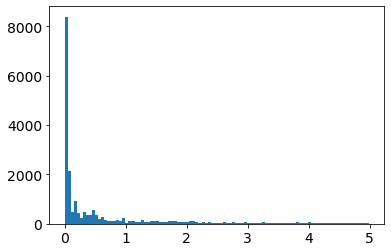

0.07


In [145]:
#insulator binding protein chip-seq data
import os

df=pd.DataFrame()
for name in ['CP190','CTCF','SuHW','Mod']:

    f1=name+'.bed'
    f2=name+'_dm3.bed'
    tmp1=pd.read_csv('Reference Files/dm6/CHIP/fix/'+f1, sep='\t', header=None)
    tmp1.columns=['chr','start','end','summit', 'fold_enrichment']
    tmp2=pd.read_csv('Reference Files/dm6/CHIP/fix/'+f2, sep='\t')
    tmp2=tmp2.drop(['chr','start','end'], axis=1)
    tmp=pd.merge(tmp1,tmp2, on=['summit','fold_enrichment'])
    tmp['TF']=name
    tmp['center']=tmp['start']+tmp['summit']
    tmp.columns=['chrom','start','end','summit','f_e','len','tags','?','fdr','TF','center']
    df=pd.concat([df,tmp])
plt.hist(df.loc[df['fdr']<5]['fdr'], bins=100)
plt.show()
df=df.loc[df['fdr']<5]
print(np.median(df['fdr']))

In [106]:
#identify if any insulator is between the pair
ts=[]
for index, row in t_all.iterrows():
    try:
        g1t=gtf_df.loc[gtf_df['gid']==row['g1']]
        g1c=g1t['chrom'].tolist()[0]
        g1t=g1t['TSS'].tolist()[0]
        g2t=gtf_df.loc[gtf_df['gid']==row['g2']]
        g2c=g2t['chrom'].tolist()[0]
        g2t=g2t['TSS'].tolist()[0]

        ttmp=df.loc[df['chrom']==g1c]

       # print(g1t, g2t)
        if g1t < g2t:
            if ttmp.loc[(ttmp['center']>=g1t)&(ttmp['center']<=g2t)].shape[0]>0:
                ts.append(1)
            else:
                ts.append(0) 
        elif g1t >= g2t:
            if ttmp.loc[(ttmp['center']<=g1t)&(ttmp['center']>=g2t)].shape[0]>0:
                ts.append(1)
            else:
                ts.append(0) 
    except:
        ts.append(np.nan)
t_all['TF']=ts
print(t_all.loc[t_all['TF']==1].shape)
print(t_all.loc[t_all['TF']==0].shape)

(25931, 17)
(6894, 17)


## Effect on coordination

### Insulator between pair?

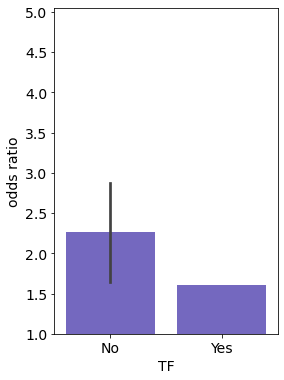

0.005967931225338394
0.08692549719658671
Ttest_indResult(statistic=-33.31288224474794, pvalue=6.551336821289032e-194)


<ipython-input-161-9fdd34025279>:47: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  print(scipy.stats.ttest_ind(ts.loc[ts['TF']=='Yes']['odds ratio'].astype(float), ts.loc[ts['TF']=='No']['odds ratio'].astype(float)))


In [161]:
os=[]
ps=[]
cs=[]
fs=[]




max_dist=2500
min_dist=100
t1=t_all.loc[(t_all['type']=='p-p')]
t1['dists']=np.abs(t1['dists'])
t1=t1.loc[(t1['dists']<max_dist)&(t1['dists']>min_dist)]
#resample distances, calculate coordination
for i in range(10000):
    #print(i)
    ts=downsample_dists(t1,25,'TF')

    ids=['No', 'Yes']

    k=0
    #print(i)
    for tt in ts:
        #print(tt)
        f=scipy.stats.fisher_exact(tt)
        #print(f)
        os.append((f[0]))
        ps.append(f[1])
        cs.append(ids[k])
        fs.append('all')

        k+=1

ts=pd.DataFrame([os,ps,cs, fs]).T
ts.columns=['odds ratio','p value','TF', 'PE']

plt.figure(figsize=(4,6))
ax=sns.barplot(data=ts, x='TF',y='odds ratio', color='slateblue', errorbar='sd')
ax.set_ylabel('odds ratio')
plt.ylim(1,max(os)+.1)
plt.savefig('Paper Figures Updated/Figure 3/TADs/insulator_2500-500_p-p.png')
plt.savefig('Paper Figures Updated/Figure 3/TADs/insulator_2500-500_p-p.pdf')
plt.show()

print(np.mean(ts.loc[ts['TF']=='Yes']['p value']))
print(np.mean(ts.loc[ts['TF']=='No']['p value']))
print(scipy.stats.ttest_ind(ts.loc[ts['TF']=='Yes']['odds ratio'].astype(float), ts.loc[ts['TF']=='No']['odds ratio'].astype(float)))

### Same or diff TAD

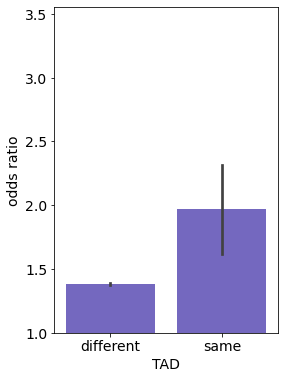

0.13845074542877372
0.02911536515975568
Ttest_indResult(statistic=-52.95730852062927, pvalue=0.0)


In [162]:
os=[]
ps=[]
cs=[]
fs=[]


max_dist=2500
min_dist=100
t1=t_all.loc[(t_all['type']=='p-p')]
t1['dists']=np.abs(t1['dists'])
t1=t1.loc[(t1['dists']<max_dist)&(t1['dists']>min_dist)]

#resample distances, calculate coordination
for i in range(10000):
    #print(i)
    ts=downsample_dists(t1,25,'tad')

    ids=['different', 'same']

    k=0
    #print(i)
    for tt in ts:
      #  print(tt)
        f=scipy.stats.fisher_exact(tt)
     #   print(f)
        os.append((f[0]))
        ps.append(f[1])
        cs.append(ids[k])
        fs.append('all')

        k+=1

ts=pd.DataFrame([os,ps,cs, fs]).T
ts.columns=['odds ratio','p value','TAD', 'PE']

plt.figure(figsize=(4,6))
ax=sns.barplot(data=ts, x='TAD',y='odds ratio', color='slateblue', errorbar='sd')
ax.set_ylabel('odds ratio')
plt.ylim(1,max(os)+.1)
plt.savefig('Paper Figures Updated/Figure 3/TADs/TAD_2500-500_p-p.png')
plt.savefig('Paper Figures Updated/Figure 3/TADs/TAD_2500-500_p-p.pdf')
plt.show()

print(np.mean(ts.loc[ts['TAD']=='different']['p value']))
print(np.mean(ts.loc[ts['TAD']=='same']['p value']))
print(scipy.stats.ttest_ind(ts.loc[ts['TAD']=='different']['odds ratio'].astype(float), ts.loc[ts['TAD']=='same']['odds ratio'].astype(float)))

### individual IBPs

CP190


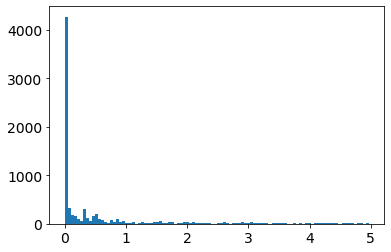

0.0
(23722, 17)
(9103, 17)


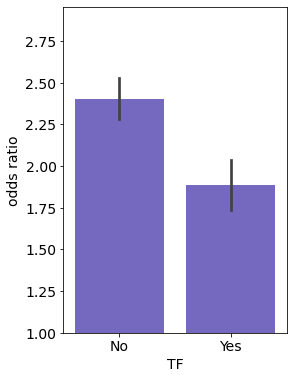

0.00015034908246908812
6.110327431285513e-07
Ttest_indResult(statistic=-85.39371447109914, pvalue=0.0)
CTCF


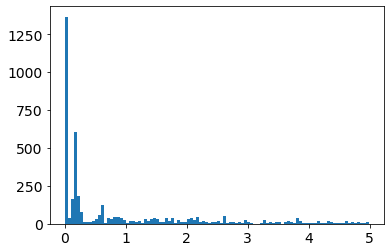

0.19
(14806, 17)
(18019, 17)


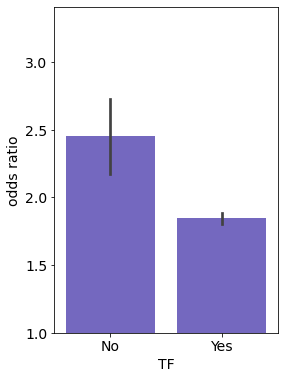

1.0702412718443009e-06
4.242107964900563e-05
Ttest_indResult(statistic=-68.60405273659305, pvalue=0.0)
SuHW


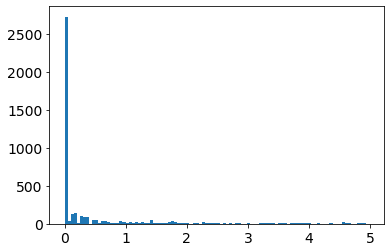

0.0
(5452, 17)
(27373, 17)


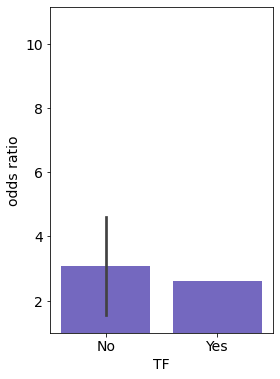

0.0012222997377098201
0.18842362952460845
Ttest_indResult(statistic=-9.659115430273774, pvalue=1.3231310205998435e-21)
Mod


<ipython-input-163-26aded60fdc4>:96: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  print(scipy.stats.ttest_ind(ts.loc[ts['TF']=='Yes']['odds ratio'].astype(float), ts.loc[ts['TF']=='No']['odds ratio'].astype(float)))


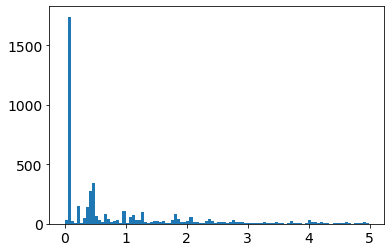

0.41
(9424, 17)
(23401, 17)


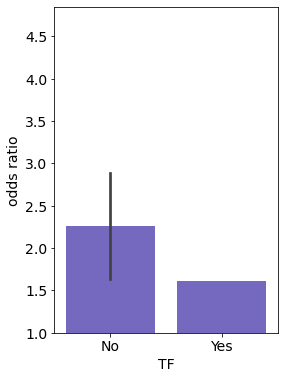

0.005967931225338394
0.08936453818943806
Ttest_indResult(statistic=-33.00209486118378, pvalue=5.0791456765853877e-191)


<ipython-input-163-26aded60fdc4>:96: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  print(scipy.stats.ttest_ind(ts.loc[ts['TF']=='Yes']['odds ratio'].astype(float), ts.loc[ts['TF']=='No']['odds ratio'].astype(float)))


In [163]:
#insulator binding protein chip-seq data
import os

df=pd.DataFrame()
for name in ['CP190','CTCF','SuHW','Mod']:
    print(name)
    f1=name+'.bed'
    f2=name+'_dm3.bed'
    tmp1=pd.read_csv('Reference Files/dm6/CHIP/fix/'+f1, sep='\t', header=None)
    tmp1.columns=['chr','start','end','summit', 'fold_enrichment']
    tmp2=pd.read_csv('Reference Files/dm6/CHIP/fix/'+f2, sep='\t')
    tmp2=tmp2.drop(['chr','start','end'], axis=1)
    tmp=pd.merge(tmp1,tmp2, on=['summit','fold_enrichment'])
    tmp['TF']=name
    tmp['center']=tmp['start']+tmp['summit']
    tmp.columns=['chrom','start','end','summit','f_e','len','tags','?','fdr','TF','center']
    df=tmp
    plt.hist(df.loc[df['fdr']<5]['fdr'], bins=100)
    plt.show()
    df=df.loc[df['fdr']<5]
    print(np.median(df['fdr']))
          
    os=[]
    ps=[]
    cs=[]
    fs=[]


    ts=[]
    for index, row in t_all.iterrows():
        try:
            g1t=gtf_df.loc[gtf_df['gid']==row['g1']]
            g1c=g1t['chrom'].tolist()[0]
            g1t=g1t['TSS'].tolist()[0]
            g2t=gtf_df.loc[gtf_df['gid']==row['g2']]
            g2c=g2t['chrom'].tolist()[0]
            g2t=g2t['TSS'].tolist()[0]

            ttmp=df.loc[df['chrom']==g1c]

           # print(g1t, g2t)
            if g1t < g2t:
                if ttmp.loc[(ttmp['center']>=g1t)&(ttmp['center']<=g2t)].shape[0]>0:
                    ts.append(1)
                else:
                    ts.append(0) 
            elif g1t >= g2t:
                if ttmp.loc[(ttmp['center']<=g1t)&(ttmp['center']>=g2t)].shape[0]>0:
                    ts.append(1)
                else:
                    ts.append(0) 
        except:
            ts.append(np.nan)
    t_all['TF']=ts
    print(t_all.loc[t_all['TF']==1].shape)
    print(t_all.loc[t_all['TF']==0].shape)

    max_dist=2500
    min_dist=100
    t1=t_all.loc[(t_all['type']=='p-p')]#&(t_all['strand'].isin(['d','u']))]
    t1['dists']=np.abs(t1['dists'])
    t1=t1.loc[(t1['dists']<max_dist)&(t1['dists']>min_dist)]
    #resample distances, calculate coordination
    for i in range(10000):
        #print(i)
        ts=downsample_dists(t1,25,'TF')

        ids=['No', 'Yes']

        k=0
        #print(i)
        for tt in ts:
           # print(tt)
            f=scipy.stats.fisher_exact(tt)
           # print(f)
            os.append((f[0]))
            ps.append(f[1])
            cs.append(ids[k])
            fs.append('all')

            k+=1

    ts=pd.DataFrame([os,ps,cs, fs]).T
    ts.columns=['odds ratio','p value','TF', 'PE']

    plt.figure(figsize=(4,6))
    ax=sns.barplot(data=ts, x='TF',y='odds ratio', color='slateblue', errorbar='sd')
    ax.set_ylabel('odds ratio')
    plt.ylim(1,max(os)+.1)
    plt.savefig('Paper Figures Updated/Figure 3/TADs/'+name+'_2500-500_p-p.png')
    plt.savefig('Paper Figures Updated/Figure 3/TADs/'+name+'_2500-500_p-p.pdf')
    plt.show()

    print(np.mean(ts.loc[ts['TF']=='Yes']['p value']))
    print(np.mean(ts.loc[ts['TF']=='No']['p value']))
    print(scipy.stats.ttest_ind(ts.loc[ts['TF']=='Yes']['odds ratio'].astype(float), ts.loc[ts['TF']=='No']['odds ratio'].astype(float)))